In [1]:
# Global switch for expensive test-set inference in legacy cells.
# The matched-count Experiment 2 section below also defines RUN_TEST_INFERENCE = False
# and links test predictions by exact selected checkpoint filename.
RUN_TEST_INFERENCE = False


# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

In [2]:
from pathlib import Path
import os
import re
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, brier_score_loss

try:
    from IPython.display import display
except Exception:
    display = None

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

EXP1_DATA_DIR = PROJECT_DATA_ROOT / "data/in-hospital-mortality"
EXP1_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP1_RESULTS_DIR = PROJECT_DATA_ROOT / "results/in-hospital-mortality"
EXP1_OUTPUT_DIR = EXP1_RESULTS_DIR / "plots"

EXP2A_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP2A_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP2A_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP2A_OUTPUT_DIR = EXP2A_RESULTS_DIR / "plots"

NETWORK = "mimic4models/keras_models/lstm.py"
EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXPECTED_EPOCHS = 100
EXP1_TIMESTEPS = [1, 2, 4, 8, 12, 24]
EXP2A_HORIZONS = [12, 24, 48, 96, 168]
EXP2A_TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]

# Keep exploratory cells permissive by default; final reported analyses should require complete seed sets.
EXP1_ONLY_COMPLETE_RUNS = False
EXP2A_ONLY_COMPLETE_RUNS = False

for _output_dir in [EXP1_OUTPUT_DIR, EXP2A_OUTPUT_DIR]:
    _output_dir.mkdir(parents=True, exist_ok=True)


def show_table(title, df, max_rows=80):
    print("\n" + title)
    print("=" * len(title))
    if df is None or len(df) == 0:
        print("<none>")
        return
    view = df.head(max_rows)
    if display is not None:
        display(view)
        if len(df) > max_rows:
            print("... {} more rows".format(len(df) - max_rows))
    else:
        print(view.to_string(index=False))


def float_token_pattern(token):
    return r"\.{}([0-9]+(?:\.[0-9]+)?)(?=\.|$)".format(token)


def clean_complete_log(df, expected_epochs=EXPECTED_EPOCHS):
    if "epoch" not in df.columns:
        return False
    epoch_values = pd.to_numeric(df["epoch"], errors="coerce")
    if epoch_values.isnull().any():
        return False
    epochs = epoch_values.astype(int).tolist()
    expected = list(range(expected_epochs))
    return len(epochs) == expected_epochs and epochs == expected


def read_validation_log(log_path, only_complete=False, expected_epochs=EXPECTED_EPOCHS):
    df = pd.read_csv(str(log_path), sep=";")
    if len(df) == 0:
        return None
    complete = clean_complete_log(df, expected_epochs=expected_epochs)
    if only_complete and not complete:
        return None
    valid = df.copy()
    for col in ["epoch", "val_auprc", "val_auroc"]:
        valid[col] = pd.to_numeric(valid[col], errors="coerce")
    valid = valid.dropna(subset=["epoch", "val_auprc", "val_auroc"])
    if len(valid) == 0:
        return None
    best_idx = valid["val_auprc"].idxmax()
    best = valid.loc[best_idx]
    return {
        "n_epochs": int(len(df)),
        "complete": bool(complete),
        "best_csv_epoch": int(best["epoch"]),
        "checkpoint_epoch": int(best["epoch"]) + 1,
        "val_auprc": float(best["val_auprc"]),
        "val_auroc": float(best["val_auroc"]),
    }


def find_selected_checkpoint(log_path, csv_epoch):
    state_dir = log_path.parent.parent / "keras_states"
    checkpoint_epoch = int(csv_epoch) + 1
    candidates = sorted(state_dir.glob("{}.epoch{}.test*.state".format(log_path.stem, checkpoint_epoch)))
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) == 0:
        return None
    raise RuntimeError("Multiple checkpoints found for {} epoch {}:\n{}".format(log_path.name, checkpoint_epoch, candidates))


def exact_prediction_for_checkpoint(results_dir, horizon_or_timestep_dir, checkpoint):
    pred_dir = results_dir / "{}h".format(horizon_or_timestep_dir) / "test_predictions"
    expected = pred_dir / (checkpoint.name + ".csv")
    return expected if expected.exists() else None


def compute_auprc(y, pred):
    precision, recall, _ = precision_recall_curve(y, pred)
    return auc(recall, precision)


def compute_metric(y, pred, metric):
    y = np.asarray(y)
    pred = np.asarray(pred)
    if metric == "auroc":
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, pred)
    if metric == "auprc":
        return compute_auprc(y, pred)
    if metric == "brier":
        return brier_score_loss(y, pred)
    raise ValueError("Unknown metric: {}".format(metric))


def compute_prediction_metrics(path):
    df = pd.read_csv(str(path))
    required = {"prediction", "y_true"}
    if not required.issubset(df.columns):
        raise ValueError("Prediction file missing required columns {}: {}".format(required, path))
    y = df["y_true"].values
    pred = df["prediction"].values
    return {
        "test_auroc": compute_metric(y, pred, "auroc"),
        "test_auprc": compute_metric(y, pred, "auprc"),
    }


def summarize_with_t_ci(df, group_cols, metric):
    rows = []
    group_cols = list(group_cols)
    if len(df) == 0:
        return pd.DataFrame(columns=group_cols + ["mean", "sd", "n", "sem", "ci95", "ci95_low", "ci95_high"])
    for keys, group in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        values = pd.to_numeric(group[metric], errors="coerce").dropna().astype(float).values
        n = len(values)
        mean = float(np.mean(values)) if n else np.nan
        sd = float(np.std(values, ddof=1)) if n > 1 else np.nan
        sem = sd / np.sqrt(n) if n > 1 else np.nan
        ci95 = float(t.ppf(0.975, n - 1) * sem) if n > 1 else np.nan
        row = dict(zip(group_cols, keys))
        row.update({
            "mean": mean,
            "sd": sd,
            "n": int(n),
            "sem": sem,
            "ci95": ci95,
            "ci95_low": mean - ci95 if n > 1 else np.nan,
            "ci95_high": mean + ci95 if n > 1 else np.nan,
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def warn_incomplete_seed_sets(df, group_cols, seed_col="seed", expected_seeds=EXPECTED_MODEL_SEEDS):
    for keys, group in df.groupby(list(group_cols)):
        seeds = set(group[seed_col].dropna().astype(int).tolist())
        missing = set(expected_seeds) - seeds
        extra = seeds - set(expected_seeds)
        if missing or extra:
            print("PARTIAL SEED SET {}: observed={} missing={} extra={}".format(keys, sorted(seeds), sorted(missing), sorted(extra)))


def compute_seed_paired_drop(df, index_cols, resolution_col, reference_value, metric, seed_col="seed", drop_col="drop"):
    join_cols = list(index_cols) + [seed_col]
    reference_col = "{}_reference".format(metric)
    ref = (
        df[df[resolution_col] == reference_value][join_cols + [metric]]
        .rename(columns={metric: reference_col})
    )
    base = df.drop([reference_col], axis=1) if reference_col in df.columns else df.copy()
    merged = base.merge(ref, on=join_cols, how="inner")
    merged[drop_col] = merged[reference_col] - merged[metric]
    return merged


def plot_mean_ci_curve(summary, x_col, ylabel, title, output_path, x_order, series_col=None, series_order=None, xlabel="", zero_line=False, raw_df=None, raw_metric=None):
    plt.figure(figsize=(7.5, 5.5))
    if series_col is None:
        sub = summary.sort_values(x_col)
        plt.errorbar(sub[x_col], sub["mean"], yerr=sub["ci95"], marker="o", capsize=4, linewidth=2, markersize=6)
        if raw_df is not None and raw_metric is not None:
            plt.scatter(raw_df[x_col], raw_df[raw_metric], alpha=0.25, s=18)
    else:
        for value in series_order:
            sub = summary[summary[series_col] == value].sort_values(x_col)
            if len(sub) == 0:
                continue
            plt.errorbar(sub[x_col], sub["mean"], yerr=sub["ci95"], marker="o", capsize=4, linewidth=2, label="{}".format(value))
            if raw_df is not None and raw_metric is not None:
                raw = raw_df[raw_df[series_col] == value]
                plt.scatter(raw[x_col], raw[raw_metric], alpha=0.20, s=16)
        plt.legend(title=series_col.replace("_", " "))
    if zero_line:
        plt.axhline(0, linestyle="--", linewidth=1, color="gray")
    plt.xticks(x_order, ["{}h".format(x) for x in x_order])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    print("Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.")

# Experiment 1 - Does measurement frequency matter?

## Experiment question and expected evidence

Question: Does prediction performance deteriorate when EHR measurements become sufficiently infrequent in the in-hospital mortality task?

Quantity: The figures below plot validation and test AUPRC/AUROC against temporal resolution. Error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: H1 is supported by relatively similar performance at fine resolutions followed by a meaningful decline at sufficiently coarse temporal resolution.

Caveat: Strict monotonic degradation is not required. Mild downsampling may have little effect or can look slightly better because of regularization or noise reduction. Validation AUPRC selects the checkpoint; AUROC and test metrics are read from that same selected epoch.


Experiment 1 selected validation checkpoints and exact test provenance


,best_csv_epoch,checkpoint,checkpoint_epoch,complete,log_path,n_epochs,prediction_path,seed,test_auprc,test_auroc,timestep,val_auprc,val_auroc
0,94,/heinz-georgenas/users/mingzhul/Simultaneous-E...,95,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,0.301848,0.736431,1.0,0.373447,0.770488
1,35,/heinz-georgenas/users/mingzhul/Simultaneous-E...,36,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,0.283528,0.713501,1.0,0.363009,0.753016
2,59,/heinz-georgenas/users/mingzhul/Simultaneous-E...,60,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,0.292707,0.732991,1.0,0.377469,0.764679
3,89,/heinz-georgenas/users/mingzhul/Simultaneous-E...,90,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,0.292709,0.733889,1.0,0.382345,0.775329
4,62,/heinz-georgenas/users/mingzhul/Simultaneous-E...,63,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,4,0.285016,0.706086,1.0,0.355122,0.752636
5,58,/heinz-georgenas/users/mingzhul/Simultaneous-E...,59,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,0.302895,0.734724,2.0,0.388768,0.772463
6,60,/heinz-georgenas/users/mingzhul/Simultaneous-E...,61,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,0.307506,0.744196,2.0,0.385208,0.766522
7,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,0.300752,0.729683,2.0,0.378108,0.763186
8,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,0.302156,0.737082,2.0,0.390922,0.766076
9,79,/heinz-georgenas/users/mingzhul/Simultaneous-E...,80,True,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,4,0.299921,0.738666,2.0,0.378478,0.769356



Experiment 1 missing exact test predictions
<none>

Experiment 1 validation AUPRC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.013742,0.384020,0.356537,0.370278,5,0.011067,0.004949,1.0
1,0.007263,0.391560,0.377034,0.384297,5,0.005850,0.002616,2.0
2,0.003310,0.377409,0.370789,0.374099,5,0.002666,0.001192,4.0
3,0.010158,0.380410,0.360094,0.370252,5,0.008181,0.003658,8.0
4,0.011828,0.375493,0.351837,0.363665,5,0.009526,0.004260,12.0
5,0.004797,0.349937,0.340342,0.345140,5,0.003864,0.001728,24.0



Experiment 1 validation AUROC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.012689,0.775918,0.750541,0.763230,5,0.010219,0.004570,1.0
1,0.004375,0.771896,0.763145,0.767521,5,0.003524,0.001576,2.0
2,0.002549,0.768333,0.763236,0.765784,5,0.002053,0.000918,4.0
3,0.004915,0.766221,0.756391,0.761306,5,0.003959,0.001770,8.0
4,0.008370,0.764583,0.747844,0.756214,5,0.006741,0.003014,12.0
5,0.002449,0.742534,0.737636,0.740085,5,0.001972,0.000882,24.0



Experiment 1 test AUPRC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.009104,0.300265,0.282058,0.291162,5,0.007332,0.003279,1.0
1,0.003669,0.306315,0.298977,0.302646,5,0.002955,0.001322,2.0
2,0.014882,0.307195,0.277430,0.292313,5,0.011986,0.005360,4.0
3,0.007049,0.295774,0.281677,0.288725,5,0.005677,0.002539,8.0
4,0.007087,0.287631,0.273458,0.280545,5,0.005707,0.002552,12.0
5,0.003722,0.279285,0.271842,0.275564,5,0.002997,0.001340,24.0



Experiment 1 test AUROC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.017145,0.741724,0.707435,0.724579,5,0.013808,0.006175,1.0
1,0.006606,0.743476,0.730265,0.736870,5,0.005320,0.002379,2.0
2,0.006778,0.730383,0.716827,0.723605,5,0.005459,0.002441,4.0
3,0.003300,0.716538,0.709938,0.713238,5,0.002658,0.001189,8.0
4,0.004977,0.714530,0.704576,0.709553,5,0.004008,0.001793,12.0
5,0.006701,0.706140,0.692738,0.699439,5,0.005397,0.002413,24.0


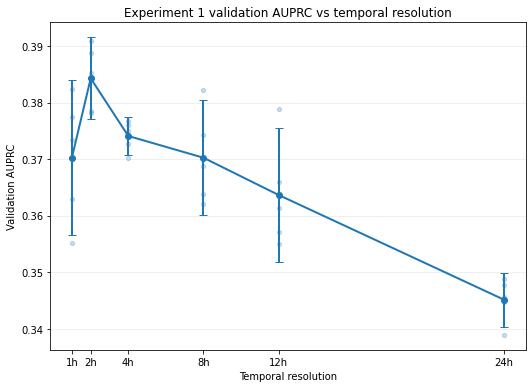

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_val_auprc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


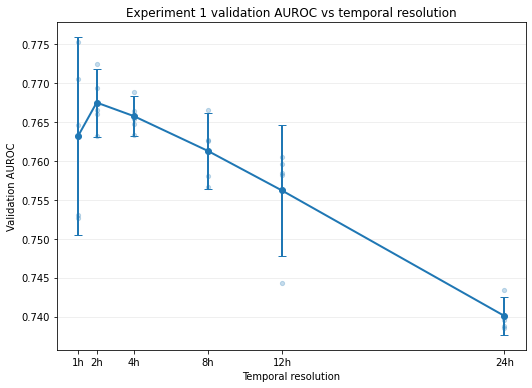

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_val_auroc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


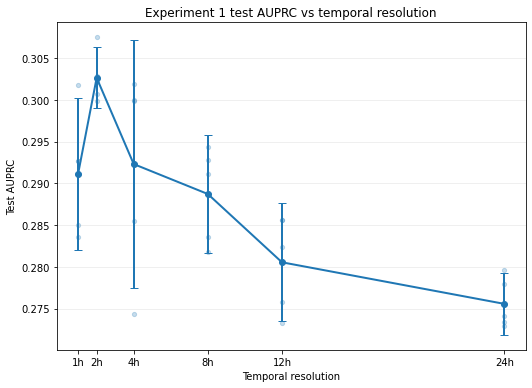

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_test_auprc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


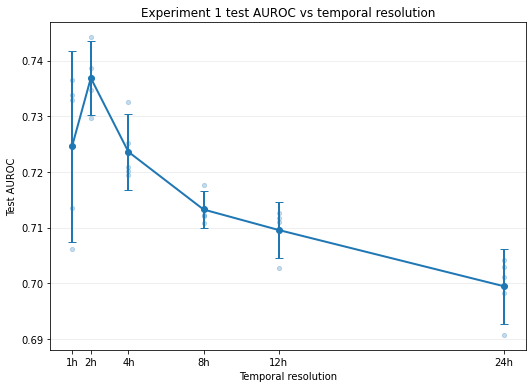

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_test_auroc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [3]:
def parse_exp1_run(path):
    m = re.search(float_token_pattern("ts") + r".*\.seed(\d+)(?:\.|$)", path.name)
    if m is not None:
        return {"timestep": float(m.group(1)), "seed": int(m.group(2))}
    m = re.search(r"seed(\d+)", path.name)
    if m is None:
        return None
    timestep = float(path.parent.parent.name.rstrip("h"))
    return {"timestep": timestep, "seed": int(m.group(1))}


exp1_rows = []
exp1_missing_predictions = []

for timestep in EXP1_TIMESTEPS:
    log_dir = EXP1_RESULTS_DIR / "{}h".format(timestep) / "keras_logs"
    if not log_dir.exists():
        print("Missing log directory:", log_dir)
        continue
    for log_path in sorted(log_dir.glob("*.seed*.csv")):
        run = parse_exp1_run(log_path)
        if run is None:
            print("Skipping unrecognized filename:", log_path.name)
            continue
        if abs(run["timestep"] - float(timestep)) > 1e-6 or run["seed"] not in EXPECTED_MODEL_SEEDS:
            continue
        best = read_validation_log(log_path, only_complete=EXP1_ONLY_COMPLETE_RUNS)
        if best is None:
            print("Skipping empty/incomplete run:", log_path.name)
            continue
        checkpoint = find_selected_checkpoint(log_path, best["best_csv_epoch"])
        prediction_path = None
        test_metrics = {"test_auroc": np.nan, "test_auprc": np.nan}
        if checkpoint is None:
            exp1_missing_predictions.append({**run, "reason": "missing selected checkpoint", "log_path": str(log_path)})
        else:
            prediction_path = exact_prediction_for_checkpoint(EXP1_RESULTS_DIR, "{}".format(timestep), checkpoint)
            if prediction_path is None:
                exp1_missing_predictions.append({**run, "reason": "missing exact prediction for selected checkpoint", "checkpoint": str(checkpoint)})
            else:
                test_metrics = compute_prediction_metrics(prediction_path)
        exp1_rows.append({
            **run,
            **best,
            "log_path": str(log_path),
            "checkpoint": None if checkpoint is None else str(checkpoint),
            "prediction_path": None if prediction_path is None else str(prediction_path),
            **test_metrics,
        })

exp1_runs = pd.DataFrame(exp1_rows).sort_values(["timestep", "seed"]).reset_index(drop=True)
exp1_missing_predictions = pd.DataFrame(exp1_missing_predictions)

show_table("Experiment 1 selected validation checkpoints and exact test provenance", exp1_runs, max_rows=200)
show_table("Experiment 1 missing exact test predictions", exp1_missing_predictions, max_rows=200)
warn_incomplete_seed_sets(exp1_runs, ["timestep"])

exp1_val_auprc_summary = summarize_with_t_ci(exp1_runs, ["timestep"], "val_auprc")
exp1_val_auroc_summary = summarize_with_t_ci(exp1_runs, ["timestep"], "val_auroc")
exp1_test_available = exp1_runs.dropna(subset=["test_auprc", "test_auroc"])
exp1_test_auprc_summary = summarize_with_t_ci(exp1_test_available, ["timestep"], "test_auprc")
exp1_test_auroc_summary = summarize_with_t_ci(exp1_test_available, ["timestep"], "test_auroc")

show_table("Experiment 1 validation AUPRC summary", exp1_val_auprc_summary)
show_table("Experiment 1 validation AUROC summary", exp1_val_auroc_summary)
show_table("Experiment 1 test AUPRC summary", exp1_test_auprc_summary)
show_table("Experiment 1 test AUROC summary", exp1_test_auroc_summary)

plot_mean_ci_curve(exp1_val_auprc_summary, "timestep", "Validation AUPRC", "Experiment 1 validation AUPRC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_val_auprc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_runs, raw_metric="val_auprc")
plot_mean_ci_curve(exp1_val_auroc_summary, "timestep", "Validation AUROC", "Experiment 1 validation AUROC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_val_auroc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_runs, raw_metric="val_auroc")

if len(exp1_test_available):
    plot_mean_ci_curve(exp1_test_auprc_summary, "timestep", "Test AUPRC", "Experiment 1 test AUPRC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_test_auprc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_test_available, raw_metric="test_auprc")
    plot_mean_ci_curve(exp1_test_auroc_summary, "timestep", "Test AUROC", "Experiment 1 test AUROC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_test_auroc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_test_available, raw_metric="test_auroc")
else:
    print("No exact validation-selected test predictions available for Experiment 1 plots.")

## Optional degradation relative to 1h

Question: How much performance is lost relative to the native 1h representation?

Quantity: Delta(r, s) = M(1h, s) - M(r, s) is computed within each model seed before summarizing across seeds. Error bars are 95% Student-t CIs across paired seed-level drops.

Evidence we are looking for: Positive degradation at coarse resolutions supports H1.

Caveat: This descriptive seed-level plot does not prove a patient-level paired test difference; it only summarizes run-to-run behavior across trained seeds.

In [4]:
exp1_test_drops = pd.DataFrame()
if len(exp1_test_available):
    exp1_test_drops = compute_seed_paired_drop(exp1_test_available, [], "timestep", 1.0, "test_auprc", drop_col="auprc_drop")
    exp1_test_drops = compute_seed_paired_drop(exp1_test_drops, [], "timestep", 1.0, "test_auroc", drop_col="auroc_drop")
    exp1_auprc_drop_summary = summarize_with_t_ci(exp1_test_drops, ["timestep"], "auprc_drop")
    exp1_auroc_drop_summary = summarize_with_t_ci(exp1_test_drops, ["timestep"], "auroc_drop")
    show_table("Experiment 1 test AUPRC drop from 1h", exp1_auprc_drop_summary)
    show_table("Experiment 1 test AUROC drop from 1h", exp1_auroc_drop_summary)
else:
    print("No Experiment 1 exact test predictions available for optional degradation summaries.")


Experiment 1 test AUPRC drop from 1h


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.000000,0.000000,0.000000,0.000000,5,0.000000,0.000000,1.0
1,0.010622,-0.000863,-0.022106,-0.011484,5,0.008554,0.003826,2.0
2,0.018974,0.017823,-0.020125,-0.001151,5,0.015281,0.006834,4.0
3,0.014491,0.016927,-0.012054,0.002436,5,0.011670,0.005219,8.0
4,0.015270,0.025887,-0.004653,0.010617,5,0.012298,0.005500,12.0
5,0.011138,0.026736,0.004460,0.015598,5,0.008970,0.004012,24.0



Experiment 1 test AUROC drop from 1h


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.000000,0.000000,0.000000,0.000000,5,0.000000,0.000000,1.0
1,0.022146,0.009855,-0.034436,-0.012291,5,0.017835,0.007976,2.0
2,0.021975,0.022950,-0.021001,0.000974,5,0.017698,0.007915,4.0
3,0.015722,0.027064,-0.004381,0.011341,5,0.012662,0.005663,8.0
4,0.019625,0.034652,-0.004599,0.015026,5,0.015806,0.007069,12.0
5,0.022077,0.047218,0.003063,0.025141,5,0.017781,0.007952,24.0


# Experiment 2A - Does frequency matter more for short horizons?

## Experiment question and expected evidence

Question: At a fixed prediction time of 24h after ICU admission, is the cost of coarser measurement frequency larger for short prediction horizons than for long prediction horizons?

Quantity: Performance-vs-resolution plots show AUPRC/AUROC by temporal resolution, with one curve per prediction horizon. Degradation plots compute Delta(h, r, s) = M(h, 1h, s) - M(h, r, s) within each seed, then summarize the paired drops across seeds with 95% Student-t CIs.

Evidence we are looking for: H2 is supported by larger positive degradation at short horizons, especially 12h, with smaller degradation at longer horizons. The longer horizons may form a plateau; perfect monotonic decline from 12h to 168h is not required.

Caveat: Raw AUPRC should not be compared directly across horizons because outcome prevalence differs by horizon. Delta relative to 1h and AUROC degradation are safer for cross-horizon sensitivity comparisons.

In [5]:
def parse_exp2a_run(path):
    m = re.search(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9]+(?:\.[0-9]+)?)(?=\.|$)"
        r".*\.seed(?P<seed>\d+)(?:\.|$)",
        path.name,
    )
    if m is None:
        return None
    return {"horizon": int(m.group("horizon")), "timestep": float(m.group("timestep")), "seed": int(m.group("seed"))}


exp2a_val_rows = []
for horizon in EXP2A_HORIZONS:
    log_dir = EXP2A_RESULTS_DIR / "{}h".format(horizon) / "keras_logs"
    if not log_dir.exists():
        print("Missing log directory:", log_dir)
        continue
    for log_path in sorted(log_dir.glob("*.csv")):
        run = parse_exp2a_run(log_path)
        if run is None:
            print("Skipping unrecognized filename:", log_path.name)
            continue
        if run["horizon"] != horizon or run["timestep"] not in EXP2A_TIMESTEPS or run["seed"] not in EXPECTED_MODEL_SEEDS:
            continue
        best = read_validation_log(log_path, only_complete=EXP2A_ONLY_COMPLETE_RUNS)
        if best is None:
            print("Skipping empty/incomplete run:", log_path.name)
            continue
        checkpoint = find_selected_checkpoint(log_path, best["best_csv_epoch"])
        exp2a_val_rows.append({
            **run,
            **best,
            "log_path": str(log_path),
            "checkpoint": None if checkpoint is None else str(checkpoint),
        })

exp2a_val_runs = pd.DataFrame(exp2a_val_rows).sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A validation-selected checkpoints", exp2a_val_runs, max_rows=300)
warn_incomplete_seed_sets(exp2a_val_runs, ["horizon", "timestep"])


Experiment 2A validation-selected checkpoints


,best_csv_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,seed,timestep,val_auprc,val_auroc
0,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,0,1.0,0.469834,0.730083
1,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,1,1.0,0.476230,0.731720
2,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,2,1.0,0.471504,0.736019
3,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,3,1.0,0.471724,0.732311
4,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,4,1.0,0.479264,0.734050
5,63,/heinz-georgenas/users/mingzhul/Simultaneous-E...,64,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,0,2.0,0.471126,0.727930
6,37,/heinz-georgenas/users/mingzhul/Simultaneous-E...,38,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,1,2.0,0.469171,0.727814
7,64,/heinz-georgenas/users/mingzhul/Simultaneous-E...,65,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,2,2.0,0.470541,0.729149
8,73,/heinz-georgenas/users/mingzhul/Simultaneous-E...,74,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,3,2.0,0.471056,0.730254
9,70,/heinz-georgenas/users/mingzhul/Simultaneous-E...,71,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,4,2.0,0.472521,0.730681


PARTIAL SEED SET (96, 1.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (168, 1.0): observed=[0, 1, 2, 3] missing=[4] extra=[]


## Validation performance vs temporal resolution

Question: Within each prediction horizon, how does validation performance change as temporal resolution becomes coarser?

Quantity: X-axis is temporal resolution; y-axis is validation AUPRC or AUROC at the validation-AUPRC-selected epoch; curves are prediction horizons; error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: Similar fine-resolution performance with degradation at coarse resolutions suggests frequency sensitivity.

Caveat: Do not interpret raw AUPRC levels across horizons as directly comparable baselines because prevalence differs across horizons.


Experiment 2A validation AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004850,0.478561,0.468861,12,0.473711,5,0.003906,0.001747,1.0
1,0.001498,0.472381,0.469385,12,0.470883,5,0.001206,0.000539,2.0
2,0.001566,0.446294,0.443162,12,0.444728,5,0.001261,0.000564,4.0
3,0.003737,0.424239,0.416765,12,0.420502,5,0.003010,0.001346,8.0
4,0.003262,0.419302,0.412777,12,0.416039,5,0.002628,0.001175,12.0
5,0.001571,0.353816,0.350673,12,0.352244,5,0.001266,0.000566,24.0
6,0.005057,0.604218,0.594105,24,0.599161,5,0.004073,0.001821,1.0
7,0.003026,0.598713,0.592662,24,0.595687,5,0.002437,0.001090,2.0
8,0.003451,0.584589,0.577687,24,0.581138,5,0.002779,0.001243,4.0
9,0.001764,0.580559,0.577031,24,0.578795,5,0.001421,0.000635,8.0



Experiment 2A validation AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.002825,0.735662,0.730012,12,0.732837,5,0.002275,0.001017,1.0
1,0.001623,0.730789,0.727542,12,0.729166,5,0.001307,0.000585,2.0
2,0.002777,0.716739,0.711185,12,0.713962,5,0.002237,0.001000,4.0
3,0.001660,0.689128,0.685808,12,0.687468,5,0.001337,0.000598,8.0
4,0.002733,0.675831,0.670366,12,0.673099,5,0.002201,0.000984,12.0
5,0.002373,0.627947,0.623200,12,0.625574,5,0.001911,0.000855,24.0
6,0.002661,0.699597,0.694275,24,0.696936,5,0.002143,0.000958,1.0
7,0.002497,0.699236,0.694242,24,0.696739,5,0.002011,0.000899,2.0
8,0.001840,0.690314,0.686635,24,0.688475,5,0.001482,0.000663,4.0
9,0.001653,0.682442,0.679136,24,0.680789,5,0.001331,0.000595,8.0


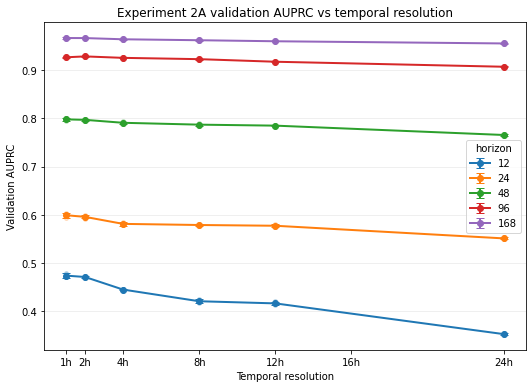

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auprc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


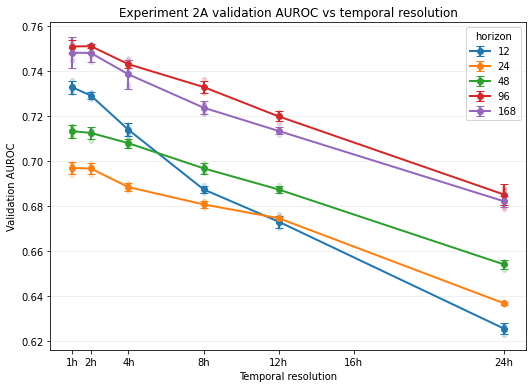

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auroc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [6]:
exp2a_val_auprc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auprc")
exp2a_val_auroc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auroc")
show_table("Experiment 2A validation AUPRC summary", exp2a_val_auprc_summary, max_rows=200)
show_table("Experiment 2A validation AUROC summary", exp2a_val_auroc_summary, max_rows=200)

plot_mean_ci_curve(
    exp2a_val_auprc_summary, "timestep", "Validation AUPRC",
    "Experiment 2A validation AUPRC vs temporal resolution",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auprc_vs_resolution_ci95.png",
    EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
    xlabel="Temporal resolution", raw_df=exp2a_val_runs, raw_metric="val_auprc",
)
plot_mean_ci_curve(
    exp2a_val_auroc_summary, "timestep", "Validation AUROC",
    "Experiment 2A validation AUROC vs temporal resolution",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auroc_vs_resolution_ci95.png",
    EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
    xlabel="Temporal resolution", raw_df=exp2a_val_runs, raw_metric="val_auroc",
)

## Validation degradation relative to 1h

Question: Is the validation-performance cost of coarsening larger for near-term prediction?

Quantity: Delta(h, r, s) = M(h, 1h, s) - M(h, r, s), computed within seed before summarizing. X-axis is prediction horizon; one curve is shown for each temporal resolution; error bars are 95% Student-t CIs across paired seed-level drops.

Evidence we are looking for: Larger positive Delta at the 12h horizon than at longer horizons supports H2.

Caveat: Delta does not need to decrease perfectly monotonically across horizons. For AUPRC, compare degradation rather than raw cross-horizon levels.


Experiment 2A validation AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004742,0.007570,-0.001913,12,0.002828,5,0.003819,0.001708,2.0
1,0.004110,0.033093,0.024874,12,0.028983,5,0.003310,0.001480,4.0
2,0.006761,0.059970,0.046448,12,0.053209,5,0.005445,0.002435,8.0
3,0.002864,0.060536,0.054808,12,0.057672,5,0.002307,0.001032,12.0
4,0.004962,0.126429,0.116505,12,0.121467,5,0.003997,0.001787,24.0
5,0.002214,0.005689,0.001260,24,0.003474,5,0.001783,0.000798,2.0
6,0.005515,0.023538,0.012508,24,0.018023,5,0.004442,0.001986,4.0
7,0.004621,0.024987,0.015745,24,0.020366,5,0.003722,0.001664,8.0
8,0.007940,0.029858,0.013979,24,0.021918,5,0.006395,0.002860,12.0
9,0.005806,0.053965,0.042353,24,0.048159,5,0.004676,0.002091,24.0



Experiment 2A validation AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.002427,0.006098,0.001244,12,0.003671,5,0.001955,0.000874,2.0
1,0.004647,0.023522,0.014228,12,0.018875,5,0.003742,0.001674,4.0
2,0.001726,0.047095,0.043643,12,0.045369,5,0.001390,0.000622,8.0
3,0.003099,0.062837,0.056639,12,0.059738,5,0.002496,0.001116,12.0
4,0.004771,0.112034,0.102492,12,0.107263,5,0.003843,0.001718,24.0
5,0.003731,0.003929,-0.003534,24,0.000198,5,0.003005,0.001344,2.0
6,0.001714,0.010176,0.006748,24,0.008462,5,0.001381,0.000617,4.0
7,0.002903,0.019050,0.013244,24,0.016147,5,0.002338,0.001046,8.0
8,0.002861,0.025131,0.019409,24,0.022270,5,0.002304,0.001030,12.0
9,0.002820,0.062921,0.057282,24,0.060102,5,0.002271,0.001016,24.0


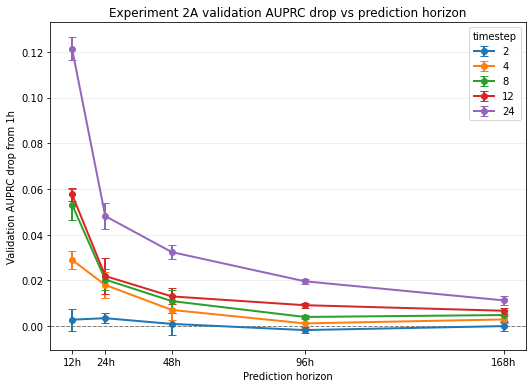

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auprc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


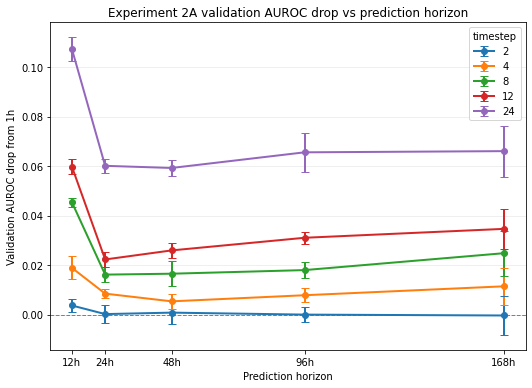

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_val_auroc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [7]:
exp2a_val_auprc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auprc", drop_col="drop")
exp2a_val_auroc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auroc", drop_col="drop")
exp2a_val_auprc_drops = exp2a_val_auprc_drops[exp2a_val_auprc_drops["timestep"] != 1.0].copy()
exp2a_val_auroc_drops = exp2a_val_auroc_drops[exp2a_val_auroc_drops["timestep"] != 1.0].copy()
exp2a_val_auprc_drop_summary = summarize_with_t_ci(exp2a_val_auprc_drops, ["horizon", "timestep"], "drop")
exp2a_val_auroc_drop_summary = summarize_with_t_ci(exp2a_val_auroc_drops, ["horizon", "timestep"], "drop")
show_table("Experiment 2A validation AUPRC drop from 1h", exp2a_val_auprc_drop_summary, max_rows=200)
show_table("Experiment 2A validation AUROC drop from 1h", exp2a_val_auroc_drop_summary, max_rows=200)

plot_mean_ci_curve(
    exp2a_val_auprc_drop_summary, "horizon", "Validation AUPRC drop from 1h",
    "Experiment 2A validation AUPRC drop vs prediction horizon",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auprc_drop_vs_horizon_ci95.png",
    EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
    xlabel="Prediction horizon", zero_line=True,
)
plot_mean_ci_curve(
    exp2a_val_auroc_drop_summary, "horizon", "Validation AUROC drop from 1h",
    "Experiment 2A validation AUROC drop vs prediction horizon",
    EXP2A_OUTPUT_DIR / "experiment2a_val_auroc_drop_vs_horizon_ci95.png",
    EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
    xlabel="Prediction horizon", zero_line=True,
)

## Test performance vs temporal resolution

Question: Do the validation-selected checkpoints show the same frequency-sensitivity pattern on the held-out test set?

Quantity: Test AUPRC/AUROC are computed only from prediction files linked exactly to the validation-selected checkpoint filename. Error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: The same threshold-like or short-horizon-sensitive degradation pattern on test data strengthens the validation finding.

Caveat: Test data are not used for model selection. Missing exact prediction files are reported rather than replaced by loose `(horizon, timestep, seed)` or mtime-based matches.


Experiment 2A exact validation-selected test predictions


,best_csv_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,prediction_path,seed,test_auprc,test_auroc,timestep,val_auprc,val_auroc
0,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,0.491179,0.746718,1.0,0.469834,0.730083
1,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,0.490433,0.741809,1.0,0.476230,0.731720
2,63,/heinz-georgenas/users/mingzhul/Simultaneous-E...,64,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,0.484856,0.739190,2.0,0.471126,0.727930
3,37,/heinz-georgenas/users/mingzhul/Simultaneous-E...,38,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,0.480740,0.740271,2.0,0.469171,0.727814
4,64,/heinz-georgenas/users/mingzhul/Simultaneous-E...,65,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,0.484753,0.740403,2.0,0.470541,0.729149
5,73,/heinz-georgenas/users/mingzhul/Simultaneous-E...,74,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,0.479901,0.738241,2.0,0.471056,0.730254
6,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,0,0.463364,0.733742,4.0,0.445222,0.714791
7,80,/heinz-georgenas/users/mingzhul/Simultaneous-E...,81,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,1,0.465747,0.735433,4.0,0.446050,0.714950
8,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,2,0.471104,0.735723,4.0,0.443186,0.711262
9,66,/heinz-georgenas/users/mingzhul/Simultaneous-E...,67,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,3,0.466318,0.731448,4.0,0.443601,0.712094



Experiment 2A missing exact test predictions


,best_csv_epoch,checkpoint,checkpoint_epoch,complete,horizon,log_path,n_epochs,reason,seed,timestep,val_auprc,val_auroc
0,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,1.0,0.471504,0.736019
1,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,1.0,0.471724,0.732311
2,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,1.0,0.479264,0.734050
3,70,/heinz-georgenas/users/mingzhul/Simultaneous-E...,71,True,12,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,2.0,0.472521,0.730681
4,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,83,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,1.0,0.598876,0.695536
5,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,1.0,0.597837,0.698371
6,81,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,1.0,0.593212,0.693935
7,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,24,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,4,2.0,0.592266,0.696849
8,84,/heinz-georgenas/users/mingzhul/Simultaneous-E...,85,True,48,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,2,1.0,0.796358,0.710600
9,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,48,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,missing exact prediction for selected checkpoint,3,1.0,0.800524,0.715425


PARTIAL SEED SET (12, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (12, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (24, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (24, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (48, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (48, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (96, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (96, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]
PARTIAL SEED SET (168, 1.0): observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET (168, 2.0): observed=[0, 1, 2, 3] missing=[4] extra=[]

Experiment 2A test AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.004735,0.495541,0.486071,12,0.490806,2,0.000527,0.000373,1.0
1,0.004156,0.486719,0.478406,12,0.482563,4,0.002612,0.001306,2.0
2,0.003701,0.470781,0.463378,12,0.467079,5,0.002981,0.001333,4.0
3,0.005576,0.417952,0.406800,12,0.412376,5,0.004491,0.002008,8.0
4,0.002329,0.418581,0.413923,12,0.416252,5,0.001875,0.000839,12.0
5,0.004451,0.343028,0.334126,12,0.338577,5,0.003585,0.001603,24.0
6,0.056866,0.666874,0.553142,24,0.610008,2,0.006329,0.004475,1.0
7,0.007333,0.607727,0.593062,24,0.600395,4,0.004608,0.002304,2.0
8,0.003723,0.602237,0.594792,24,0.598515,5,0.002998,0.001341,4.0
9,0.002902,0.581486,0.575683,24,0.578585,5,0.002337,0.001045,8.0



Experiment 2A test AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.031184,0.775448,0.713080,12,0.744264,2,0.003471,0.002454,1.0
1,0.001614,0.741141,0.737912,12,0.739526,4,0.001014,0.000507,2.0
2,0.002112,0.736210,0.731985,12,0.734098,5,0.001701,0.000761,4.0
3,0.003506,0.697109,0.690096,12,0.693602,5,0.002824,0.001263,8.0
4,0.002875,0.690560,0.684809,12,0.687685,5,0.002316,0.001036,12.0
5,0.004207,0.628873,0.620460,12,0.624666,5,0.003388,0.001515,24.0
6,0.032489,0.735067,0.670089,24,0.702578,2,0.003616,0.002557,1.0
7,0.003750,0.699194,0.691693,24,0.695444,4,0.002357,0.001178,2.0
8,0.002396,0.696502,0.691710,24,0.694106,5,0.001930,0.000863,4.0
9,0.001659,0.676680,0.673362,24,0.675021,5,0.001336,0.000598,8.0


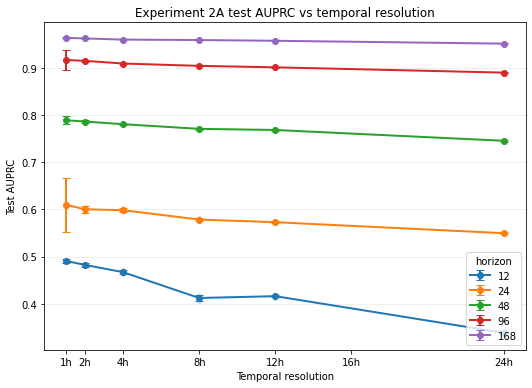

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auprc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


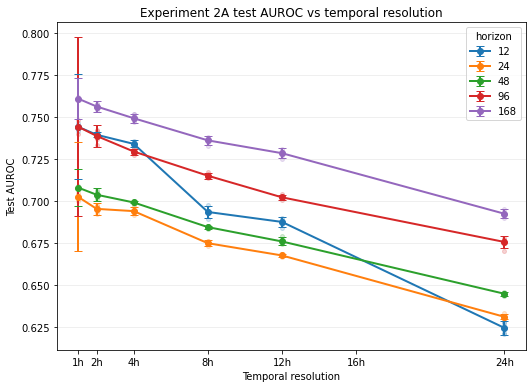

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auroc_vs_resolution_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [8]:
exp2a_test_rows = []
exp2a_missing_predictions = []

for _, row in exp2a_val_runs.iterrows():
    if not row.get("checkpoint"):
        exp2a_missing_predictions.append({**row.to_dict(), "reason": "missing selected checkpoint"})
        continue
    checkpoint = Path(row["checkpoint"])
    prediction_path = exact_prediction_for_checkpoint(EXP2A_RESULTS_DIR, "{}".format(int(row["horizon"])), checkpoint)
    if prediction_path is None:
        exp2a_missing_predictions.append({**row.to_dict(), "reason": "missing exact prediction for selected checkpoint"})
        continue
    metrics = compute_prediction_metrics(prediction_path)
    exp2a_test_rows.append({**row.to_dict(), **metrics, "prediction_path": str(prediction_path)})

exp2a_test_runs = pd.DataFrame(exp2a_test_rows)
if len(exp2a_test_runs):
    exp2a_test_runs = exp2a_test_runs.sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
exp2a_missing_predictions = pd.DataFrame(exp2a_missing_predictions)

show_table("Experiment 2A exact validation-selected test predictions", exp2a_test_runs, max_rows=300)
show_table("Experiment 2A missing exact test predictions", exp2a_missing_predictions, max_rows=300)
warn_incomplete_seed_sets(exp2a_test_runs, ["horizon", "timestep"])

if len(exp2a_test_runs):
    exp2a_test_auprc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auprc")
    exp2a_test_auroc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auroc")
    show_table("Experiment 2A test AUPRC summary", exp2a_test_auprc_summary, max_rows=200)
    show_table("Experiment 2A test AUROC summary", exp2a_test_auroc_summary, max_rows=200)
    plot_mean_ci_curve(
        exp2a_test_auprc_summary, "timestep", "Test AUPRC",
        "Experiment 2A test AUPRC vs temporal resolution",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auprc_vs_resolution_ci95.png",
        EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
        xlabel="Temporal resolution", raw_df=exp2a_test_runs, raw_metric="test_auprc",
    )
    plot_mean_ci_curve(
        exp2a_test_auroc_summary, "timestep", "Test AUROC",
        "Experiment 2A test AUROC vs temporal resolution",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auroc_vs_resolution_ci95.png",
        EXP2A_TIMESTEPS, series_col="horizon", series_order=EXP2A_HORIZONS,
        xlabel="Temporal resolution", raw_df=exp2a_test_runs, raw_metric="test_auroc",
    )
else:
    print("No exact validation-selected Experiment 2A test predictions available.")

## Test degradation relative to 1h

Question: On the held-out test set, is the performance cost of coarsening larger for near-term prediction?

Quantity: Test Delta(h, r, s) is computed within each seed from exact validation-selected predictions, then summarized across seeds with 95% Student-t CIs.

Evidence we are looking for: Larger positive Delta at short horizons, especially 12h, supports H2.

Caveat: The model-seed CI describes variability across trained models. It is not the same uncertainty estimate as the paired patient bootstrap below.


Experiment 2A test AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.021416,0.029423,-0.013408,12,0.008008,2,0.002384,0.001685,2.0
1,0.019878,0.046128,0.006373,12,0.026251,2,0.002212,0.001564,4.0
2,0.041018,0.118441,0.036404,12,0.077423,2,0.004565,0.003228,8.0
3,0.006967,0.080869,0.066935,12,0.073902,2,0.000775,0.000548,12.0
4,0.025714,0.176399,0.124971,12,0.150685,2,0.002862,0.002024,24.0
5,0.049744,0.055477,-0.044012,24,0.005732,2,0.005537,0.003915,2.0
6,0.092435,0.102204,-0.082665,24,0.009770,2,0.010288,0.007275,4.0
7,0.034230,0.066046,-0.002414,24,0.031816,2,0.003810,0.002694,8.0
8,0.059354,0.096001,-0.022707,24,0.036647,2,0.006606,0.004671,12.0
9,0.066363,0.127742,-0.004985,24,0.061379,2,0.007386,0.005223,24.0



Experiment 2A test AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.038050,0.042584,-0.033517,12,0.004533,2,0.004235,0.002995,2.0
1,0.041928,0.051605,-0.032251,12,0.009677,2,0.004667,0.003300,4.0
2,0.037164,0.088073,0.013746,12,0.050910,2,0.004136,0.002925,8.0
3,0.015923,0.072473,0.040627,12,0.056550,2,0.001772,0.001253,12.0
4,0.045415,0.162714,0.071884,12,0.117299,2,0.005055,0.003574,24.0
5,0.034643,0.039829,-0.029458,24,0.005185,2,0.003856,0.002727,2.0
6,0.063246,0.071361,-0.055131,24,0.008115,2,0.007039,0.004978,4.0
7,0.019507,0.046696,0.007682,24,0.027189,2,0.002171,0.001535,8.0
8,0.038092,0.072241,-0.003943,24,0.034149,2,0.004240,0.002998,12.0
9,0.029538,0.101768,0.042693,24,0.072231,2,0.003288,0.002325,24.0


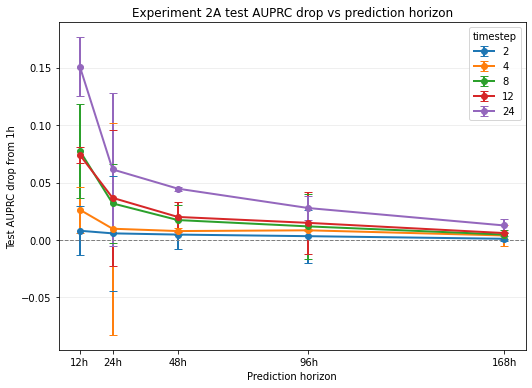

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auprc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


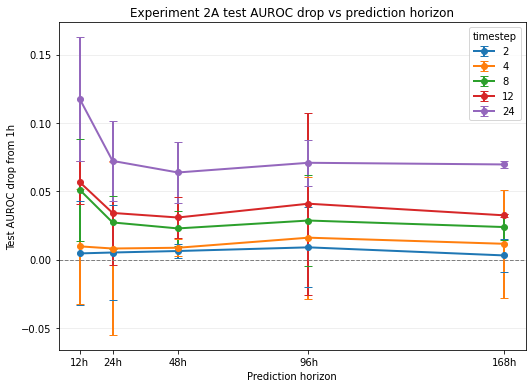

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_auroc_drop_vs_horizon_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [9]:
if len(exp2a_test_runs):
    exp2a_test_auprc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auprc", drop_col="drop")
    exp2a_test_auroc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auroc", drop_col="drop")
    exp2a_test_auprc_drops = exp2a_test_auprc_drops[exp2a_test_auprc_drops["timestep"] != 1.0].copy()
    exp2a_test_auroc_drops = exp2a_test_auroc_drops[exp2a_test_auroc_drops["timestep"] != 1.0].copy()
    exp2a_test_auprc_drop_summary = summarize_with_t_ci(exp2a_test_auprc_drops, ["horizon", "timestep"], "drop")
    exp2a_test_auroc_drop_summary = summarize_with_t_ci(exp2a_test_auroc_drops, ["horizon", "timestep"], "drop")
    show_table("Experiment 2A test AUPRC drop from 1h", exp2a_test_auprc_drop_summary, max_rows=200)
    show_table("Experiment 2A test AUROC drop from 1h", exp2a_test_auroc_drop_summary, max_rows=200)
    plot_mean_ci_curve(
        exp2a_test_auprc_drop_summary, "horizon", "Test AUPRC drop from 1h",
        "Experiment 2A test AUPRC drop vs prediction horizon",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auprc_drop_vs_horizon_ci95.png",
        EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
        xlabel="Prediction horizon", zero_line=True,
    )
    plot_mean_ci_curve(
        exp2a_test_auroc_drop_summary, "horizon", "Test AUROC drop from 1h",
        "Experiment 2A test AUROC drop vs prediction horizon",
        EXP2A_OUTPUT_DIR / "experiment2a_test_auroc_drop_vs_horizon_ci95.png",
        EXP2A_HORIZONS, series_col="timestep", series_order=[x for x in EXP2A_TIMESTEPS if x != 1],
        xlabel="Prediction horizon", zero_line=True,
    )
else:
    print("No Experiment 2A exact test predictions available for degradation plots.")

## Paired patient bootstrap analysis

Question: Are the observed test-set differences between 1h and coarser resolutions stable to resampling the patient population?

Quantity: For AUROC, AUPRC, and Brier, predictions are paired on the same stays/patients and bootstrapped by patient. Positive differences mean the 1h/reference condition is better; for Brier this uses the reversed sign because lower Brier is better.

Evidence we are looking for: Positive paired differences whose 95% patient-bootstrap CI excludes zero indicate stable test-set degradation for that horizon/resolution/seed.

Caveat: This is a patient-population uncertainty estimate, not a model-seed CI and not a replacement for the descriptive across-seed plots above.

In [10]:
def extract_patient_id(stay):
    stay = str(stay)
    m = re.match(r"^(\d+)_episode", stay)
    if m:
        return m.group(1)
    return stay.split("_")[0]


def load_prediction_frame(path):
    df = pd.read_csv(str(path))
    required = {"stay", "prediction", "y_true"}
    if not required.issubset(df.columns):
        raise ValueError("Prediction file missing required columns {}: {}".format(required, path))
    df = df.copy()
    df["patient_id"] = df["stay"].apply(extract_patient_id)
    return df


def metric_difference(left_value, right_value, metric):
    if metric == "brier":
        return right_value - left_value
    return left_value - right_value


def paired_patient_bootstrap(reference_df, comparison_df, metric, n_boot=2000, random_state=12345):
    ref = reference_df[["stay", "patient_id", "y_true", "prediction"]].rename(columns={"y_true": "y_ref", "prediction": "pred_ref"})
    comp = comparison_df[["stay", "patient_id", "y_true", "prediction"]].rename(columns={"y_true": "y_comp", "prediction": "pred_comp"})
    paired = ref.merge(comp, on=["stay", "patient_id"], how="inner")
    if len(paired) != len(reference_df) or len(paired) != len(comparison_df):
        raise ValueError("Reference/comparison cohorts differ: paired={}, ref={}, comparison={}".format(len(paired), len(reference_df), len(comparison_df)))
    if not np.array_equal(paired["y_ref"].values, paired["y_comp"].values):
        raise ValueError("Labels differ between paired prediction files.")
    paired = paired.reset_index(drop=True)
    y = paired["y_ref"].values
    pred_ref = paired["pred_ref"].values
    pred_comp = paired["pred_comp"].values
    ref_metric = compute_metric(y, pred_ref, metric)
    comp_metric = compute_metric(y, pred_comp, metric)
    observed_diff = metric_difference(ref_metric, comp_metric, metric)
    rng = np.random.RandomState(random_state)
    patient_ids = np.asarray(sorted(paired["patient_id"].unique()))
    patient_to_indices = {pid: np.where(paired["patient_id"].values == pid)[0] for pid in patient_ids}
    boot_diffs = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        sampled_indices = np.concatenate([patient_to_indices[pid] for pid in sampled_patients])
        y_b = y[sampled_indices]
        ref_b = compute_metric(y_b, pred_ref[sampled_indices], metric)
        comp_b = compute_metric(y_b, pred_comp[sampled_indices], metric)
        diff_b = metric_difference(ref_b, comp_b, metric)
        if not np.isnan(diff_b):
            boot_diffs.append(diff_b)
    ci_low, ci_high = np.percentile(np.asarray(boot_diffs), [2.5, 97.5])
    return {
        "reference_1h": ref_metric,
        "comparison": comp_metric,
        "difference": observed_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n_patients": int(len(patient_ids)),
        "n_stays": int(len(paired)),
        "n_boot_valid": int(len(boot_diffs)),
    }


EXP2A_BOOT_METRICS = ["auroc", "auprc", "brier"]
EXP2A_N_BOOT = int(os.environ.get("EXP2A_N_BOOT", "2000"))
EXP2A_BOOTSTRAP_SEED = 12345
exp2a_prediction_frames = {}

if len(exp2a_test_runs):
    for _, row in exp2a_test_runs.iterrows():
        exp2a_prediction_frames[(row["horizon"], row["timestep"], row["seed"])] = load_prediction_frame(row["prediction_path"])

exp2a_bootstrap_rows = []
for horizon in EXP2A_HORIZONS:
    for seed in sorted(EXPECTED_MODEL_SEEDS):
        reference_key = (horizon, 1.0, seed)
        if reference_key not in exp2a_prediction_frames:
            continue
        reference_df = exp2a_prediction_frames[reference_key]
        for timestep in [x for x in EXP2A_TIMESTEPS if x != 1]:
            comparison_key = (horizon, float(timestep), seed)
            if comparison_key not in exp2a_prediction_frames:
                continue
            comparison_df = exp2a_prediction_frames[comparison_key]
            for metric in EXP2A_BOOT_METRICS:
                result = paired_patient_bootstrap(
                    reference_df,
                    comparison_df,
                    metric=metric,
                    n_boot=EXP2A_N_BOOT,
                    random_state=EXP2A_BOOTSTRAP_SEED + horizon * 100 + timestep * 10 + seed,
                )
                exp2a_bootstrap_rows.append({
                    "horizon": horizon,
                    "timestep": timestep,
                    "seed": seed,
                    "metric": metric,
                    **result,
                })

exp2a_bootstrap = pd.DataFrame(exp2a_bootstrap_rows)
if len(exp2a_bootstrap):
    exp2a_bootstrap = exp2a_bootstrap.sort_values(["metric", "horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A seed-level paired patient-bootstrap 95% CI", exp2a_bootstrap, max_rows=300)


Experiment 2A seed-level paired patient-bootstrap 95% CI


,ci_high,ci_low,comparison,difference,horizon,metric,n_boot_valid,n_patients,n_stays,reference_1h,seed,timestep
0,0.020561,-0.007108,0.484856,0.006322,12,auprc,2000,5643,6757,0.491179,0,2
1,0.020344,-0.002876,0.480740,0.009693,12,auprc,2000,5643,6757,0.490433,1,2
2,0.042814,0.013041,0.463364,0.027815,12,auprc,2000,5643,6757,0.491179,0,4
3,0.039996,0.009152,0.465747,0.024686,12,auprc,2000,5643,6757,0.490433,1,4
4,0.100797,0.061471,0.410528,0.080651,12,auprc,2000,5643,6757,0.491179,0,8
5,0.092499,0.054682,0.416239,0.074194,12,auprc,2000,5643,6757,0.490433,1,8
6,0.093557,0.053871,0.417825,0.073353,12,auprc,2000,5643,6757,0.491179,0,12
7,0.093523,0.055306,0.415983,0.074450,12,auprc,2000,5643,6757,0.490433,1,12
8,0.174931,0.129322,0.338470,0.152708,12,auprc,2000,5643,6757,0.491179,0,24
9,0.172864,0.124922,0.341772,0.148661,12,auprc,2000,5643,6757,0.490433,1,24


# Experiment 2B - Why does frequency matter?

## A/B/C/D definitions

A: Native observations represented on the standard 1h grid.

B: Structured r-hour measurement selection/thinning; retained observations keep original timestamps and are represented on the downstream 1h grid.

C: Random matched-count thinning; for each patient-variable, retain the same effective number of observations as B but choose positions randomly from originally occupied 1h cells. Downstream representation remains 1h.

D: Standard r-hour discretization using the ordinary r-hour grid and therefore fewer recurrent steps.

Question: Which parts of the frequency effect are associated with structured observation loss, temporal placement, and representation/grid changes?

Evidence we are looking for: A > B suggests structured observation loss removes predictive information; B != C suggests temporal placement matters beyond observation count; B != D suggests representation/grid effects matter in addition to selection.

Caveat: A/B/C/D are not an additive causal decomposition. B vs D is not a pure sequence-length contrast because temporal alignment, masks/imputation trajectories, temporal precision, and representation resolution also change.

## Run availability / diagnostics

The code below preserves the strict provenance chain: validation log -> validation-AUPRC-selected epoch -> exact checkpoint filename -> exact test prediction filename.

In [11]:
from pathlib import Path
import re
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    brier_score_loss,
)

try:
    from IPython.display import display
except Exception:
    display = None


# ============================================================
# Configuration
# ============================================================

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/length-of-stay"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit"
)

NETWORK = "mimic4models/keras_models/lstm.py"

# Primary matched-count configuration.
TARGET_RS = [4]
HORIZONS = [12, 24, 48, 96, 168]
EXPECTED_MODEL_SEEDS = [0, 1, 2, 3, 4]
EXPECTED_EPOCHS = 100
REQUIRE_COMPLETE_FOR_FINAL = True

# Never launch test inference unless this is explicitly changed by the user.
RUN_TEST_INFERENCE = False

N_BOOT = int(os.environ.get("EXP2B_N_BOOT", "2000"))
BOOTSTRAP_SEED = 12345

EXPECTED_CONFIG = {
    "network": NETWORK,
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_size": 8,
    "epochs": 100,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "sampling_seed": 100,
}

CONDITION_ORDER = ["A", "B", "C", "D"]
PRIMARY_CONTRASTS = [("A", "B"), ("B", "C"), ("B", "D")]
OPTIONAL_CONTRASTS = [("A", "D")]
METRICS = ["auroc", "auprc", "brier"]


def show_table(title, df, max_rows=50):
    print("\n" + title)
    print("=" * len(title))
    if df is None or len(df) == 0:
        print("<none>")
        return
    view = df.head(max_rows)
    if display is not None:
        display(view)
        if len(df) > max_rows:
            print("... {} more rows".format(len(df) - max_rows))
    else:
        print(view.to_string(index=False))


def compute_auprc(y, pred):
    precision, recall, _ = precision_recall_curve(y, pred)
    return auc(recall, precision)


def compute_metric(y, pred, metric):
    y = np.asarray(y)
    pred = np.asarray(pred)
    if metric == "auroc":
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, pred)
    if metric == "auprc":
        return compute_auprc(y, pred)
    if metric == "brier":
        return brier_score_loss(y, pred)
    raise ValueError("Unknown metric: {}".format(metric))


def metric_difference(left_value, right_value, metric):
    # Positive always means the left condition performs better.
    if metric == "brier":
        return right_value - left_value
    return left_value - right_value


def extract_patient_id(stay):
    stay = str(stay)
    m = re.match(r"^(\d+)_episode", stay)
    if m:
        return m.group(1)
    return stay.split("_")[0]


In [12]:
# ============================================================
# Robust run parsing and exact checkpoint/prediction matching
# ============================================================

def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    if cast is not None:
        return cast(value)
    return value


def parse_run_from_filename(path, target_r):
    """Parse validation log/checkpoint/prediction identity from a filename."""
    name = path.name
    horizon = _search(r"\.h(\d+)", name, int)
    timestep = _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float)
    model_seed = _search(r"\.seed(\d+)(?:\.|$)", name, int)

    dim = _search(r"\.n(\d+)", name, int)
    dropout = _search(r"\.d([0-9.]+)\.dep", name, float)
    depth = _search(r"\.dep(\d+)", name, int)
    batch_size = _search(r"\.bs(\d+)", name, int)
    target_repl_coef = _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0)
    has_l1 = re.search(r"\.L1[0-9.eE+-]+", name) is not None
    has_l2 = re.search(r"\.L2[0-9.eE+-]+", name) is not None

    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        sampling_strategy = "none"
        sampling_interval = None
        sampling_seed = None
    else:
        sampling_strategy = sample.group("strategy")
        sampling_interval = int(sample.group("interval"))
        sampling_seed = sample.group("sseed")
        sampling_seed = int(sampling_seed) if sampling_seed is not None else None

    condition = None
    r = target_r
    if sampling_strategy == "none" and timestep is not None and abs(timestep - 1.0) < 1e-6:
        condition = "A"
        r = target_r
    elif (sampling_strategy == "structured" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "B"
        r = sampling_interval
    elif (sampling_strategy == "random_matched" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "C"
        r = sampling_interval
    elif (sampling_strategy == "none" and timestep is not None
          and abs(timestep - float(target_r)) < 1e-6):
        condition = "D"
        r = target_r

    return {
        "filename": name,
        "horizon": horizon,
        "r": r,
        "condition": condition,
        "timestep": timestep,
        "model_seed": model_seed,
        "dim": dim,
        "depth": depth,
        "dropout": dropout,
        "batch_size": batch_size,
        "sampling_strategy": sampling_strategy,
        "sampling_interval": sampling_interval,
        "sampling_seed": sampling_seed,
        "target_repl_coef": target_repl_coef,
        "has_l1": has_l1,
        "has_l2": has_l2,
    }


def hyperparameter_mismatch_reason(run):
    reasons = []
    checks = [
        ("dim", EXPECTED_CONFIG["dim"]),
        ("depth", EXPECTED_CONFIG["depth"]),
        ("batch_size", EXPECTED_CONFIG["batch_size"]),
    ]
    for key, expected in checks:
        if run.get(key) != expected:
            reasons.append("{}={} expected {}".format(key, run.get(key), expected))
    if run.get("dropout") is None or abs(run.get("dropout") - EXPECTED_CONFIG["dropout"]) > 1e-9:
        reasons.append("dropout={} expected {}".format(run.get("dropout"), EXPECTED_CONFIG["dropout"]))
    if run.get("target_repl_coef") != EXPECTED_CONFIG["target_repl_coef"]:
        reasons.append("target_repl_coef={} expected {}".format(
            run.get("target_repl_coef"), EXPECTED_CONFIG["target_repl_coef"]))
    if run.get("has_l1"):
        reasons.append("L1 suffix present; expected l1=0")
    if run.get("has_l2"):
        reasons.append("L2 suffix present; expected l2=0")
    if run.get("condition") == "C" and run.get("sampling_seed") != EXPECTED_CONFIG["sampling_seed"]:
        reasons.append("sampling_seed={} expected {}".format(
            run.get("sampling_seed"), EXPECTED_CONFIG["sampling_seed"]))
    if run.get("model_seed") not in EXPECTED_MODEL_SEEDS:
        reasons.append(
            "model_seed={} not in expected {}".format(
                run.get("model_seed"),
                EXPECTED_MODEL_SEEDS,
            )
        )        
    return "; ".join(reasons)


def condition_description(condition):
    if condition == "A":
        return "standard 1h"
    if condition == "B":
        return "structured-r + 1h"
    if condition == "C":
        return "random matched-count-r + 1h"
    if condition == "D":
        return "existing r-hour representation"
    return "outside A/B/C/D"


def read_validation_log(log_path):
    df = pd.read_csv(str(log_path), sep=";")
    if len(df) == 0:
        return None
    n_epochs = len(df)
    if "epoch" in df.columns:
        epoch_values = pd.to_numeric(df["epoch"], errors="coerce")
        complete = (not epoch_values.isnull().any()
                    and len(epoch_values) == EXPECTED_EPOCHS
                    and epoch_values.astype(int).tolist() == list(range(EXPECTED_EPOCHS)))
    else:
        complete = False
    valid = df.copy()
    for col in ["epoch", "val_auprc", "val_auroc"]:
        valid[col] = pd.to_numeric(valid[col], errors="coerce")
    valid = valid.dropna(subset=["epoch", "val_auprc", "val_auroc"])
    if len(valid) == 0:
        return None
    best_idx = valid["val_auprc"].idxmax()
    best = valid.loc[best_idx]
    return {
        "n_epochs": n_epochs,
        "complete": complete,
        "best_val_epoch": int(best["epoch"]),
        "best_val_auprc": float(best["val_auprc"]),
        "val_auroc_at_best_auprc": float(best["val_auroc"]),
    }


def find_selected_checkpoint(log_path, best_val_epoch):
    # CSVLogger epoch is zero-indexed in this benchmark; checkpoint names are one-indexed.
    checkpoint_epoch = int(best_val_epoch) + 1
    state_dir = log_path.parent.parent / "keras_states"
    pattern = "{}.epoch{}.test*.state".format(log_path.stem, checkpoint_epoch)
    candidates = sorted(state_dir.glob(pattern))
    if len(candidates) == 0:
        return None
    if len(candidates) > 1:
        raise RuntimeError("Multiple selected checkpoints for {} epoch {}:\n{}".format(
            log_path.name, checkpoint_epoch, candidates))
    return candidates[0]


def exact_prediction_path(checkpoint, horizon):
    pred_dir = OUT / "{}h".format(horizon) / "test_predictions"
    expected_name = checkpoint.name + ".csv"
    if not pred_dir.exists():
        return pred_dir / expected_name, []
    matches = [p for p in pred_dir.iterdir() if p.name == expected_name]
    if len(matches) > 1:
        raise RuntimeError("Multiple exact prediction files for checkpoint {}:\n{}".format(
            checkpoint.name, matches))
    return pred_dir / expected_name, matches


def find_normalizer_for_run(run):
    if run["condition"] == "C":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), int(run["sampling_seed"]), float(run["timestep"]))
    elif run["condition"] == "B":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), float(run["timestep"]))
    else:
        pattern = (
            "fixed_horizon_icu_exit_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(float(run["timestep"]))
    candidates = sorted(NORM.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def build_test_inference_command(run, checkpoint, prediction_path):
    normalizer = find_normalizer_for_run(run)
    output_dir = OUT / "{}h".format(int(run["horizon"]))
    cmd = [
        "python", "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(DATA),
        "--output_dir", str(output_dir),
        "--normalizer_state", str(normalizer),
        "--load_state", str(checkpoint),
        "--horizon", str(int(run["horizon"])),
        "--timestep", str(float(run["timestep"])),
        "--seed", str(int(run["model_seed"])),
        "--dim", str(EXPECTED_CONFIG["dim"]),
        "--depth", str(EXPECTED_CONFIG["depth"]),
        "--dropout", str(EXPECTED_CONFIG["dropout"]),
        "--rec_dropout", str(EXPECTED_CONFIG["rec_dropout"]),
        "--batch_size", str(EXPECTED_CONFIG["batch_size"]),
        "--lr", str(EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXPECTED_CONFIG["beta_1"]),
        "--l1", str(EXPECTED_CONFIG["l1"]),
        "--l2", str(EXPECTED_CONFIG["l2"]),
        "--target_repl_coef", str(EXPECTED_CONFIG["target_repl_coef"]),
        "--sampling_strategy", run["sampling_strategy"],
    ]
    if run["condition"] in ("B", "C"):
        cmd += ["--sampling_interval", str(int(run["sampling_interval"]))]
    if run["condition"] == "C":
        cmd += ["--sampling_seed", str(int(run["sampling_seed"]))]
    return cmd


def load_prediction_csv(path):
    df = pd.read_csv(str(path))
    required = {"stay", "prediction", "y_true"}
    if not required.issubset(df.columns):
        raise ValueError("Prediction file missing required columns {}: {}".format(required, path))
    df = df.copy()
    df["patient_id"] = df["stay"].apply(extract_patient_id)
    return df


def test_metrics(df):
    y = df["y_true"].values
    pred = df["prediction"].values
    return {
        "test_auroc": compute_metric(y, pred, "auroc"),
        "test_auprc": compute_metric(y, pred, "auprc"),
        "test_brier": compute_metric(y, pred, "brier"),
        "n_test_stays": int(len(df)),
        "n_test_patients": int(df["patient_id"].nunique()),
    }

In [13]:
# ============================================================
# Discover validation logs, select checkpoints, and load exact test predictions
# ============================================================

status_rows = []
excluded_rows = []
partial_rows = []
missing_prediction_rows = []
included_rows = []
prediction_frames = {}

for target_r in TARGET_RS:
    for log_path in sorted(OUT.glob("*h/keras_logs/*.csv")):
        parsed = parse_run_from_filename(log_path, target_r)
        if parsed["horizon"] not in HORIZONS:
            continue
        parsed["log_path"] = str(log_path)
        parsed["condition_description"] = condition_description(parsed["condition"])

        if parsed["condition"] is None:
            row = dict(parsed)
            row["exclude_reason"] = "outside A/B/C/D for r={}".format(target_r)
            excluded_rows.append(row)
            continue

        mismatch = hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            excluded_rows.append(row)
            continue

        val = read_validation_log(log_path)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            excluded_rows.append(row)
            continue
        parsed.update(val)

        checkpoint = find_selected_checkpoint(log_path, parsed["best_val_epoch"])
        parsed["selected_val_epoch"] = parsed["best_val_epoch"]
        parsed["val_auprc"] = parsed["best_val_auprc"]
        parsed["val_auroc"] = parsed["val_auroc_at_best_auprc"]
        parsed["selected_checkpoint"] = str(checkpoint) if checkpoint is not None else None
        parsed["checkpoint"] = str(checkpoint) if checkpoint is not None else None

        status_rows.append(dict(parsed))

        if not parsed["complete"]:
            partial_rows.append(dict(parsed))
            if REQUIRE_COMPLETE_FOR_FINAL:
                continue

        if checkpoint is None:
            row = dict(parsed)
            row["missing_reason"] = "MISSING SELECTED CHECKPOINT"
            missing_prediction_rows.append(row)
            continue

        expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
        parsed["prediction_path"] = str(expected_prediction)

        if len(matches) == 0:
            if RUN_TEST_INFERENCE and parsed["complete"]:
                cmd = build_test_inference_command(parsed, checkpoint, expected_prediction)
                print("Running test inference for selected checkpoint:")
                print(" ".join(cmd))
                subprocess.check_call(cmd)
                expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
            if len(matches) == 0:
                row = dict(parsed)
                row["missing_reason"] = "MISSING TEST PREDICTION"
                missing_prediction_rows.append(row)
                continue

        pred_path = matches[0]
        pred_df = load_prediction_csv(pred_path)
        metrics = test_metrics(pred_df)
        parsed.update(metrics)
        parsed["prediction_path"] = str(pred_path)

        key = (parsed["horizon"], parsed["r"], parsed["condition"], parsed["model_seed"])
        if key in prediction_frames:
            raise RuntimeError("Duplicate included run identity {}. Refusing to mix runs.".format(key))
        prediction_frames[key] = pred_df
        included_rows.append(dict(parsed))

status_df = pd.DataFrame(status_rows)
excluded_df = pd.DataFrame(excluded_rows)
partial_df = pd.DataFrame(partial_rows)
missing_predictions_df = pd.DataFrame(missing_prediction_rows)
run_results = pd.DataFrame(included_rows)

if len(run_results):
    run_results = run_results.sort_values(
        ["horizon", "r", "condition", "model_seed"]
    ).reset_index(drop=True)

# Detect duplicate run rows after filtering before summaries.
if len(run_results):
    dup_cols = ["horizon", "r", "condition", "model_seed"]
    dup = run_results[run_results.duplicated(dup_cols, keep=False)]
    if len(dup):
        raise RuntimeError("Duplicate final run identities found:\n{}".format(dup[dup_cols + ["log_path"]]))

show_table("A. Included complete runs", run_results)
show_table("B. Partial runs excluded from final analysis", partial_df)
show_table("C. Hyperparameter-mismatched / outside-condition runs excluded", excluded_df)
show_table("D. Missing exact test predictions", missing_predictions_df)

if len(status_df):
    status_cols = [
        "condition", "horizon", "r", "timestep", "model_seed", "sampling_seed",
        "n_epochs", "complete", "best_val_epoch", "best_val_auprc",
        "val_auroc_at_best_auprc", "selected_checkpoint",
    ]
    show_table("Run-status table", status_df[[c for c in status_cols if c in status_df.columns]])

if len(run_results):
    expected_seed_set = set(EXPECTED_MODEL_SEEDS)
    for keys, group in run_results.groupby(["horizon", "r", "condition"]):
        observed = set(group["model_seed"].astype(int).tolist())
        if observed != expected_seed_set:
            print("PARTIAL SEED SET: h={} r={} condition={} observed={} missing={} extra={}".format(
                keys[0], keys[1], keys[2], sorted(observed),
                sorted(expected_seed_set - observed), sorted(observed - expected_seed_set)))


A. Included complete runs


,batch_size,best_val_auprc,best_val_epoch,checkpoint,complete,condition,condition_description,depth,dim,dropout,...,selected_checkpoint,selected_val_epoch,target_repl_coef,test_auprc,test_auroc,test_brier,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc
0,8,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,0.0,0.491179,0.746718,0.162099,1.0,0.469834,0.730083,0.730083
1,8,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,44,0.0,0.490433,0.741809,0.163353,1.0,0.476230,0.731720,0.731720
2,8,0.445222,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,99,0.0,0.463364,0.733742,0.165455,4.0,0.445222,0.714791,0.714791
3,8,0.446050,80,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,80,0.0,0.465747,0.735433,0.165029,4.0,0.446050,0.714950,0.714950
4,8,0.443186,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,0.0,0.471104,0.735723,0.164762,4.0,0.443186,0.711262,0.711262
5,8,0.443601,66,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,66,0.0,0.466318,0.731448,0.165956,4.0,0.443601,0.712094,0.712094
6,8,0.445579,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,95,0.0,0.468864,0.734144,0.165369,4.0,0.445579,0.716713,0.716713
7,8,0.602418,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,91,0.0,0.605532,0.700021,0.215801,1.0,0.602418,0.699105,0.699105
8,8,0.579304,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,0.0,0.597439,0.692043,0.217449,4.0,0.579304,0.688079,0.688079
9,8,0.585147,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,D,existing r-hour representation,2,16,0.3,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,95,0.0,0.603037,0.696884,0.216479,4.0,0.585147,0.690083,0.690083



B. Partial runs excluded from final analysis


,batch_size,best_val_auprc,best_val_epoch,checkpoint,complete,condition,condition_description,depth,dim,dropout,...,sampling_interval,sampling_seed,sampling_strategy,selected_checkpoint,selected_val_epoch,target_repl_coef,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc
0,8,0.603464,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,False,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,99,0.0,1.0,0.603464,0.697736,0.697736
1,8,0.796485,38,/heinz-georgenas/users/mingzhul/Simultaneous-E...,False,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,38,0.0,1.0,0.796485,0.713611,0.713611



C. Hyperparameter-mismatched / outside-condition runs excluded


...

... 50 more rows

D. Missing exact test predictions


,batch_size,best_val_auprc,best_val_epoch,checkpoint,complete,condition,condition_description,depth,dim,dropout,...,sampling_interval,sampling_seed,sampling_strategy,selected_checkpoint,selected_val_epoch,target_repl_coef,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc
0,8,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,91,0.0,1.0,0.471504,0.736019,0.736019
1,8,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,0.0,1.0,0.471724,0.732311,0.732311
2,8,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,86,0.0,1.0,0.479264,0.734050,0.734050
3,8,0.966470,88,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,0.0,1.0,0.966470,0.745209,0.745209
4,8,0.967215,54,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,54,0.0,1.0,0.967215,0.748879,0.748879
5,8,0.598876,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,0.0,1.0,0.598876,0.695536,0.695536
6,8,0.597837,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,0.0,1.0,0.597837,0.698371,0.698371
7,8,0.593212,81,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,81,0.0,1.0,0.593212,0.693935,0.693935
8,8,0.796358,84,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,84,0.0,1.0,0.796358,0.710600,0.710600
9,8,0.800524,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,A,standard 1h,2,16,0.3,...,None,None,none,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,0.0,1.0,0.800524,0.715425,0.715425



Run-status table


,condition,horizon,r,timestep,model_seed,sampling_seed,n_epochs,complete,best_val_epoch,best_val_auprc,val_auroc_at_best_auprc,selected_checkpoint
0,A,12,4,1.0,0,None,100,True,93,0.469834,0.730083,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,A,12,4,1.0,1,None,100,True,44,0.476230,0.731720,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,A,12,4,1.0,2,None,100,True,91,0.471504,0.736019,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,A,12,4,1.0,3,None,100,True,92,0.471724,0.732311,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,A,12,4,1.0,4,None,100,True,86,0.479264,0.734050,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,D,12,4,4.0,0,None,100,True,99,0.445222,0.714791,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,D,12,4,4.0,1,None,100,True,80,0.446050,0.714950,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,D,12,4,4.0,2,None,100,True,92,0.443186,0.711262,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,D,12,4,4.0,3,None,100,True,66,0.443601,0.712094,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,D,12,4,4.0,4,None,100,True,95,0.445579,0.716713,/heinz-georgenas/users/mingzhul/Simultaneous-E...


PARTIAL SEED SET: h=12 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 condition=A observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=96 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=168 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]


In [14]:
# ============================================================
# A/B/C/D run-level and mean +/- 95% Student-t CI summaries
# ============================================================

RUN_LEVEL_COLUMNS = [
    "horizon", "r", "condition", "sampling_strategy", "sampling_seed",
    "timestep", "model_seed", "n_epochs", "complete", "selected_val_epoch",
    "val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier",
    "checkpoint", "prediction_path",
]

EXP2B_CONDITION_METRICS = ["val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier"]

if len(run_results):
    run_level = run_results[[c for c in RUN_LEVEL_COLUMNS if c in run_results.columns]].copy()
    show_table("E. A/B/C/D run-level results", run_level, max_rows=200)

    exp2b_summary_parts = []
    for metric_col in EXP2B_CONDITION_METRICS:
        metric_summary = summarize_with_t_ci(
            run_results,
            ["horizon", "r", "condition"],
            metric_col,
        )
        metric_summary.insert(3, "metric", metric_col)
        exp2b_summary_parts.append(metric_summary)
    summary = pd.concat(exp2b_summary_parts, ignore_index=True)
    show_table("F. A/B/C/D mean across seeds +/- 95% Student-t CI", summary, max_rows=300)
else:
    run_level = pd.DataFrame()
    summary = pd.DataFrame()
    print("No complete A/B/C/D runs with exact test predictions were included.")


E. A/B/C/D run-level results


,horizon,r,condition,sampling_strategy,sampling_seed,timestep,model_seed,n_epochs,complete,selected_val_epoch,val_auprc,val_auroc,test_auprc,test_auroc,test_brier,checkpoint,prediction_path
0,12,4,A,none,None,1.0,0,100,True,93,0.469834,0.730083,0.491179,0.746718,0.162099,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,12,4,A,none,None,1.0,1,100,True,44,0.476230,0.731720,0.490433,0.741809,0.163353,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,12,4,D,none,None,4.0,0,100,True,99,0.445222,0.714791,0.463364,0.733742,0.165455,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,12,4,D,none,None,4.0,1,100,True,80,0.446050,0.714950,0.465747,0.735433,0.165029,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,12,4,D,none,None,4.0,2,100,True,92,0.443186,0.711262,0.471104,0.735723,0.164762,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,12,4,D,none,None,4.0,3,100,True,66,0.443601,0.712094,0.466318,0.731448,0.165956,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,12,4,D,none,None,4.0,4,100,True,95,0.445579,0.716713,0.468864,0.734144,0.165369,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,24,4,A,none,None,1.0,1,100,True,91,0.602418,0.699105,0.605532,0.700021,0.215801,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,24,4,D,none,None,4.0,0,100,True,82,0.579304,0.688079,0.597439,0.692043,0.217449,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,24,4,D,none,None,4.0,1,100,True,95,0.585147,0.690083,0.603037,0.696884,0.216479,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...



F. A/B/C/D mean across seeds +/- 95% Student-t CI


,ci95,ci95_high,ci95_low,metric,condition,horizon,mean,n,r,sd,sem
0,0.040632,0.513664,0.432400,val_auprc,A,12,0.473032,2,4,0.004522,0.003198
1,0.001566,0.446294,0.443162,val_auprc,D,12,0.444728,5,4,0.001261,0.000564
2,NaN,NaN,NaN,val_auprc,A,24,0.602418,1,4,NaN,NaN
3,0.003451,0.584589,0.577687,val_auprc,D,24,0.581138,5,4,0.002779,0.001243
4,0.013510,0.812956,0.785937,val_auprc,A,48,0.799446,2,4,0.001504,0.001063
5,0.002289,0.793324,0.788746,val_auprc,D,48,0.791035,5,4,0.001843,0.000824
6,0.001049,0.928001,0.925903,val_auprc,A,96,0.926952,2,4,0.000117,0.000083
7,0.001227,0.927084,0.924630,val_auprc,D,96,0.925857,5,4,0.000988,0.000442
8,0.013982,0.981192,0.953228,val_auprc,A,168,0.967210,2,4,0.001556,0.001100
9,0.000982,0.965402,0.963438,val_auprc,D,168,0.964420,5,4,0.000791,0.000354


In [15]:

# ============================================================
# Paired patient-level bootstrap contrasts
# ============================================================

def paired_prediction_frame(left_df, right_df):
    left = left_df[["stay", "patient_id", "y_true", "prediction"]].rename(
        columns={"y_true": "y_left", "prediction": "pred_left"})
    right = right_df[["stay", "patient_id", "y_true", "prediction"]].rename(
        columns={"y_true": "y_right", "prediction": "pred_right"})
    paired = left.merge(right, on=["stay", "patient_id"], how="inner")
    if len(paired) != len(left_df) or len(paired) != len(right_df):
        raise ValueError("Paired conditions contain different stay IDs: paired={}, left={}, right={}".format(
            len(paired), len(left_df), len(right_df)))
    if not np.array_equal(paired["y_left"].values, paired["y_right"].values):
        raise ValueError("Paired conditions contain different y_true labels.")
    return paired


def contrast_point_from_paired(paired, metric):
    y = paired["y_left"].values
    left_value = compute_metric(y, paired["pred_left"].values, metric)
    right_value = compute_metric(y, paired["pred_right"].values, metric)
    return left_value, right_value, metric_difference(left_value, right_value, metric)


def paired_patient_bootstrap(left_df, right_df, metric, n_boot=N_BOOT, random_state=BOOTSTRAP_SEED):
    paired = paired_prediction_frame(left_df, right_df)
    left_value, right_value, point = contrast_point_from_paired(paired, metric)
    rng = np.random.RandomState(random_state)
    patient_ids = np.asarray(sorted(paired["patient_id"].unique()))
    paired = paired.reset_index(drop=True)
    y = paired["y_left"].values
    pred_left = paired["pred_left"].values
    pred_right = paired["pred_right"].values
    patient_to_indices = {
        pid: np.where(paired["patient_id"].values == pid)[0]
        for pid in patient_ids
    }
    boot = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        sampled_indices = np.concatenate([patient_to_indices[pid] for pid in sampled_patients])
        left_b = compute_metric(y[sampled_indices], pred_left[sampled_indices], metric)
        right_b = compute_metric(y[sampled_indices], pred_right[sampled_indices], metric)
        diff = metric_difference(left_b, right_b, metric)
        if not np.isnan(diff):
            boot.append(diff)
    boot = np.asarray(boot)
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return {
        "left_metric": left_value,
        "right_metric": right_value,
        "difference": point,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n_patients": int(len(patient_ids)),
        "n_stays": int(len(paired)),
        "boot_diffs": boot,
    }


def available_conditions(horizon, r, model_seed):
    return set(run_results[
        (run_results["horizon"] == horizon)
        & (run_results["r"] == r)
        & (run_results["model_seed"] == model_seed)
    ]["condition"].tolist()) if len(run_results) else set()


contrast_rows = []
all_contrasts = [(x[0], x[1], True) for x in PRIMARY_CONTRASTS] + [(x[0], x[1], False) for x in OPTIONAL_CONTRASTS]

if len(run_results):
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            for model_seed in sorted(run_results["model_seed"].unique()):
                have = available_conditions(horizon, r, model_seed)
                for left, right, is_primary in all_contrasts:
                    if left not in have or right not in have:
                        continue
                    left_df = prediction_frames[(horizon, r, left, model_seed)]
                    right_df = prediction_frames[(horizon, r, right, model_seed)]
                    for metric in METRICS:
                        result = paired_patient_bootstrap(
                            left_df,
                            right_df,
                            metric=metric,
                            n_boot=N_BOOT,
                            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000
                                          + int(r) * 1000 + int(model_seed) * 10
                                          + METRICS.index(metric)),
                        )
                        contrast_rows.append({
                            "horizon": horizon,
                            "r": r,
                            "model_seed": model_seed,
                            "contrast": "{}_vs_{}".format(left, right),
                            "left_condition": left,
                            "right_condition": right,
                            "primary": is_primary,
                            "metric": metric,
                            "left_metric": result["left_metric"],
                            "right_metric": result["right_metric"],
                            "difference": result["difference"],
                            "ci_low": result["ci_low"],
                            "ci_high": result["ci_high"],
                            "n_patients": result["n_patients"],
                            "n_stays": result["n_stays"],
                        })

seed_level_contrasts = pd.DataFrame(contrast_rows)
if len(seed_level_contrasts):
    seed_level_contrasts = seed_level_contrasts.sort_values(
        ["horizon", "r", "contrast", "metric", "model_seed"]
    ).reset_index(drop=True)
show_table("G. Seed-level bootstrap contrasts", seed_level_contrasts, max_rows=300)



G. Seed-level bootstrap contrasts


,ci_high,ci_low,contrast,difference,horizon,left_condition,left_metric,metric,model_seed,n_patients,n_stays,primary,r,right_condition,right_metric
0,0.042986,0.013529,A_vs_D,0.027815,12,A,0.491179,auprc,0,5643,6757,False,4,D,0.463364
1,0.038832,0.010207,A_vs_D,0.024686,12,A,0.490433,auprc,1,5643,6757,False,4,D,0.465747
2,0.020918,0.005389,A_vs_D,0.012976,12,A,0.746718,auroc,0,5643,6757,False,4,D,0.733742
3,0.014371,-0.001627,A_vs_D,0.006377,12,A,0.741809,auroc,1,5643,6757,False,4,D,0.735433
4,0.005508,0.001439,A_vs_D,0.003356,12,A,0.162099,brier,0,5643,6757,False,4,D,0.165455
5,0.003563,-0.000419,A_vs_D,0.001676,12,A,0.163353,brier,1,5643,6757,False,4,D,0.165029
6,0.014510,-0.008774,A_vs_D,0.002495,24,A,0.605532,auprc,1,5643,6757,False,4,D,0.603037
7,0.010360,-0.003846,A_vs_D,0.003137,24,A,0.700021,auroc,1,5643,6757,False,4,D,0.696884
8,0.002674,-0.001310,A_vs_D,0.000678,24,A,0.215801,brier,1,5643,6757,False,4,D,0.216479
9,0.015786,-0.000217,A_vs_D,0.007954,48,A,0.789727,auprc,0,5643,6757,False,4,D,0.781773


In [16]:
# ============================================================
# Across-seed summaries and patient-bootstrap CI for mean contrast
# ============================================================

def across_seed_bootstrap(horizon, r, left, right, metric, model_seeds, n_boot=N_BOOT, random_state=BOOTSTRAP_SEED):
    paired_by_seed = {}
    first_patients = None
    for seed in model_seeds:
        paired = paired_prediction_frame(
            prediction_frames[(horizon, r, left, seed)],
            prediction_frames[(horizon, r, right, seed)],
        )
        patients = np.asarray(sorted(paired["patient_id"].unique()))
        if first_patients is None:
            first_patients = patients
        elif not np.array_equal(first_patients, patients):
            raise ValueError("Patient sets differ across model seeds for h={} r={} {}_vs_{}".format(
                horizon, r, left, right))
        paired_by_seed[seed] = paired.reset_index(drop=True)

    rng = np.random.RandomState(random_state)
    patient_ids = first_patients
    arrays_by_seed = {}
    patient_to_indices = {}
    for seed, paired in paired_by_seed.items():
        arrays_by_seed[seed] = {
            "y": paired["y_left"].values,
            "pred_left": paired["pred_left"].values,
            "pred_right": paired["pred_right"].values,
        }
        patient_to_indices[seed] = {
            pid: np.where(paired["patient_id"].values == pid)[0]
            for pid in patient_ids
        }

    boot_means = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        seed_diffs = []
        for seed, paired_arrays in arrays_by_seed.items():
            sampled_indices = np.concatenate([patient_to_indices[seed][pid] for pid in sampled_patients])
            y_b = paired_arrays["y"][sampled_indices]
            left_b = compute_metric(y_b, paired_arrays["pred_left"][sampled_indices], metric)
            right_b = compute_metric(y_b, paired_arrays["pred_right"][sampled_indices], metric)
            diff = metric_difference(left_b, right_b, metric)
            if not np.isnan(diff):
                seed_diffs.append(diff)
        if len(seed_diffs):
            boot_means.append(float(np.mean(seed_diffs)))
    boot_means = np.asarray(boot_means)
    return np.percentile(boot_means, [2.5, 97.5])


summary_rows = []
if len(seed_level_contrasts):
    group_cols = ["horizon", "r", "contrast", "left_condition", "right_condition", "primary", "metric"]
    for keys, group in seed_level_contrasts.groupby(group_cols):
        horizon, r, contrast, left, right, primary, metric = keys
        seeds = sorted(group["model_seed"].unique())
        diffs = group["difference"].values
        ci_low, ci_high = across_seed_bootstrap(
            horizon, r, left, right, metric, seeds,
            n_boot=N_BOOT,
            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000
                          + len(contrast) * 10 + METRICS.index(metric)),
        )
        summary_rows.append({
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "primary": primary,
            "metric": metric,
            "n_seeds": int(len(seeds)),
            "expected_seeds": len(EXPECTED_MODEL_SEEDS),
            "complete_seed_set": set(seeds) == set(EXPECTED_MODEL_SEEDS),
            "mean_difference": float(np.mean(diffs)),
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "patient_bootstrap_ci_low": float(ci_low),
            "patient_bootstrap_ci_high": float(ci_high),
        })
        if set(seeds) != set(EXPECTED_MODEL_SEEDS):
            print("PARTIAL SEED SET: h={} r={} contrast={} metric={} observed={} missing={} extra={}".format(
                horizon, r, contrast, metric, sorted(seeds),
                sorted(set(EXPECTED_MODEL_SEEDS) - set(seeds)),
                sorted(set(seeds) - set(EXPECTED_MODEL_SEEDS))))

across_seed_summary = pd.DataFrame(summary_rows)
if len(across_seed_summary):
    across_seed_summary = across_seed_summary.sort_values(
        ["horizon", "r", "contrast", "metric"]
    ).reset_index(drop=True)
show_table("H. Across-seed contrast summary + bootstrap CI", across_seed_summary, max_rows=300)

PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=auroc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=brier observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=auprc observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=auroc observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=brier observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=auroc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=brier observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=96 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SE

,complete_seed_set,contrast,expected_seeds,horizon,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,primary,r,sd_difference
0,False,A_vs_D,5,12,0.026251,auprc,2,0.039649,0.012626,False,4,0.002212
1,False,A_vs_D,5,12,0.009677,auroc,2,0.016763,0.002539,False,4,0.004667
2,False,A_vs_D,5,12,0.002516,brier,2,0.004313,0.000661,False,4,0.001188
3,False,A_vs_D,5,24,0.002495,auprc,1,0.014045,-0.008449,False,4,NaN
4,False,A_vs_D,5,24,0.003137,auroc,1,0.010475,-0.004016,False,4,NaN
5,False,A_vs_D,5,24,0.000678,brier,1,0.002735,-0.001267,False,4,NaN
6,False,A_vs_D,5,48,0.007736,auprc,2,0.015228,0.000328,False,4,0.000308
7,False,A_vs_D,5,48,0.008669,auroc,2,0.015066,0.002427,False,4,0.000706
8,False,A_vs_D,5,48,0.000745,brier,2,0.002855,-0.001397,False,4,0.000602
9,False,A_vs_D,5,96,0.008382,auprc,2,0.012894,0.003821,False,4,0.000091


## Condition-level performance

Question: How do raw A/B/C/D validation-selected test metrics compare within each horizon and r?

Quantity: Each plot shows condition-level performance by model seed, with the condition mean and 95% Student-t CI across model seeds. For Brier, lower raw values are better even though the contrast plots use a positive-is-left-better sign convention.

Evidence we are looking for: A drop from A to B suggests structured observation loss; differences between B and C suggest temporal placement matters after matching count; differences between B and D suggest representation/grid effects in addition to structured selection.

Caveat: Raw condition plots are descriptive and are not the paired patient-bootstrap formal contrasts.

## Primary contrasts

Question: Are A-vs-B, B-vs-C, and B-vs-D differences stable to paired patient-level resampling?

Quantity: Points are mean differences across available model seeds; error bars are 95% paired patient-bootstrap CIs for the mean contrast. Positive values mean the left condition is better; for Brier, the sign is reversed so positive still means left/reference is better.

Evidence we are looking for: A reproducible non-zero contrast supports the corresponding mechanism question.

Caveat: B vs D is not a pure sequence-length contrast, and the contrasts are not an additive causal decomposition.

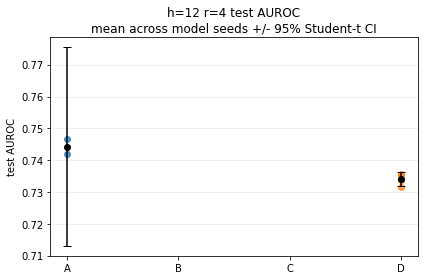

/home/mingzhul/projects/Simultaneous-EHR/repos/mimic-iv-benchmarks/.conda/mimic4bench/lib/python3.6/site-packages/numpy/core/_asarray.py:83: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


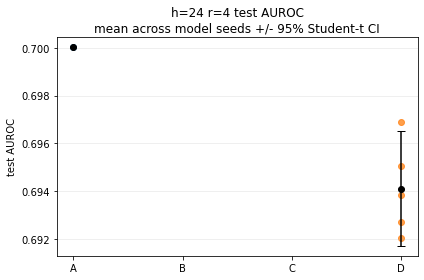

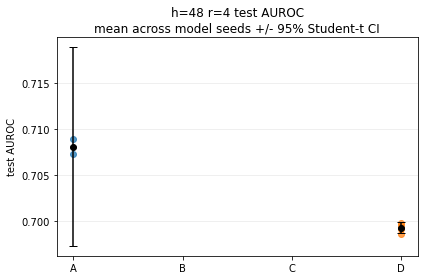

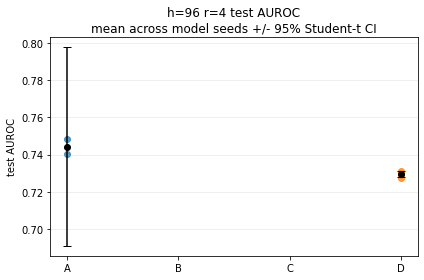

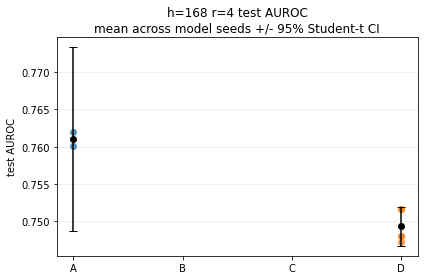

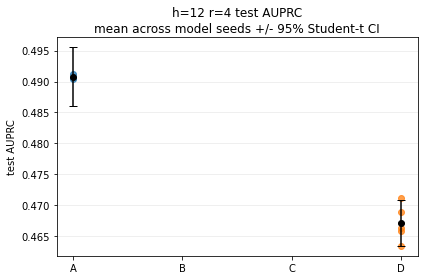

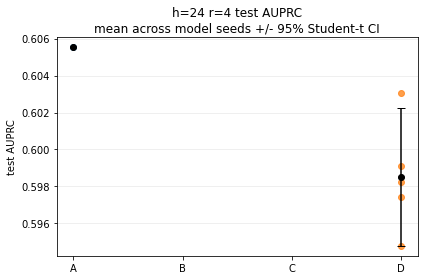

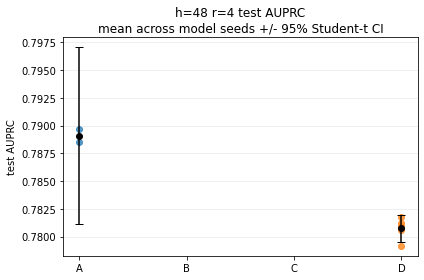

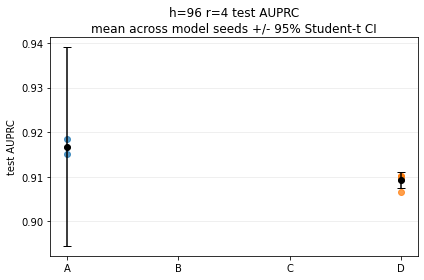

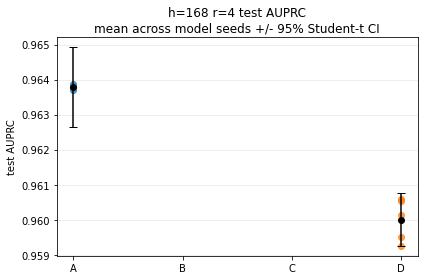

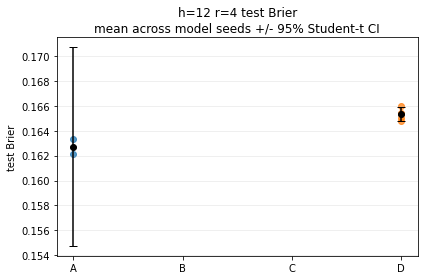

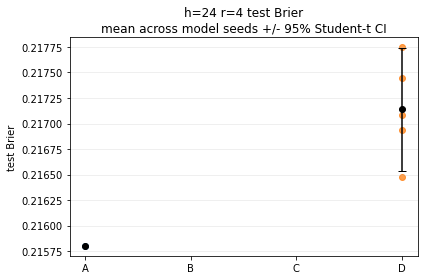

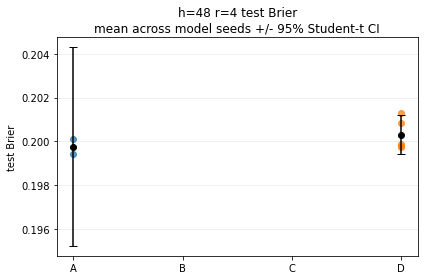

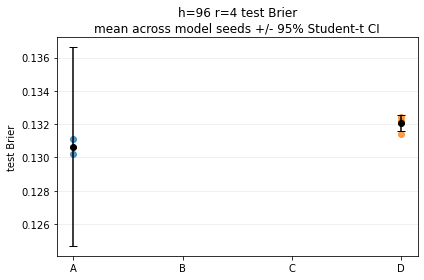

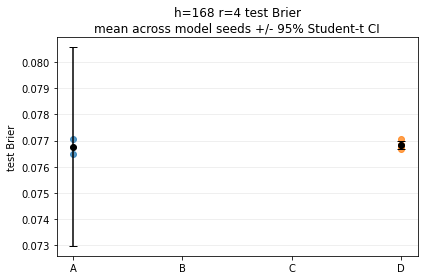

In [17]:
# ============================================================
# Diagnostic plots
# ============================================================

def plot_metric_by_condition(metric_col, ylabel):
    if not len(run_results):
        return
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            sub = run_results[(run_results["horizon"] == horizon) & (run_results["r"] == r)]
            if len(sub) == 0:
                continue
            metric_summary = summarize_with_t_ci(sub, ["condition"], metric_col)
            x_pos = {cond: i for i, cond in enumerate(CONDITION_ORDER)}
            plt.figure(figsize=(6, 4))
            for cond in CONDITION_ORDER:
                csub = sub[sub["condition"] == cond]
                if len(csub) == 0:
                    continue
                x = np.repeat(x_pos[cond], len(csub))
                plt.scatter(x, csub[metric_col].values, alpha=0.75, label=cond)
                srow = metric_summary[metric_summary["condition"] == cond]
                if len(srow):
                    plt.errorbar(
                        [x_pos[cond]],
                        [srow["mean"].iloc[0]],
                        yerr=[srow["ci95"].iloc[0]],
                        fmt="o", color="black", capsize=4,
                    )
            plt.xticks(range(len(CONDITION_ORDER)), CONDITION_ORDER)
            plt.title("h={} r={} {}\nmean across model seeds +/- 95% Student-t CI".format(horizon, r, ylabel))
            plt.ylabel(ylabel)
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


def plot_primary_contrasts(metric):
    if not len(across_seed_summary):
        return
    sub = across_seed_summary[(across_seed_summary["metric"] == metric) & (across_seed_summary["primary"])]
    for horizon in sorted(sub["horizon"].unique()):
        for r in sorted(sub["r"].unique()):
            g = sub[(sub["horizon"] == horizon) & (sub["r"] == r)]
            if len(g) == 0:
                continue
            labels = g["contrast"].tolist()
            x = np.arange(len(labels))
            y = g["mean_difference"].values
            lo = g["patient_bootstrap_ci_low"].values
            hi = g["patient_bootstrap_ci_high"].values
            yerr = np.vstack([y - lo, hi - y])
            plt.figure(figsize=(7, 4))
            plt.axhline(0, color="gray", linewidth=1)
            plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5)
            plt.xticks(x, labels, rotation=20)
            plt.title("h={} r={} {} contrasts\n95% paired patient-bootstrap CI".format(horizon, r, metric.upper()))
            plt.ylabel("left condition better (+)")
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


plot_metric_by_condition("test_auroc", "test AUROC")
plot_metric_by_condition("test_auprc", "test AUPRC")
plot_metric_by_condition("test_brier", "test Brier")
for metric in METRICS:
    plot_primary_contrasts(metric)

# Experiment 2C - Does the mechanism depend on r?

Question: Does the A/B/C/D mechanism change as the frequency reduction becomes more severe, for example r=2, r=4, and r=8?

Quantity: The matched-count code above loops over `TARGET_RS`. If multiple r values are available, the run diagnostics, condition-level summaries, and primary contrast plots are stratified by r.

Evidence we are looking for: The observed results may show little degradation at r=2, moderate effects at r=4, and stronger degradation at r=8, but that pattern is not assumed.

Caveat: Do not fabricate missing r values. Interpret only the r values with complete exact-checkpoint predictions and reported seed availability.